# Ocean Plastic Cleanup: Physically Realistic Drift Model & Dynamic Routing Optimizer

This notebook implements a **physically realistic plastic drift model** and **dynamic routing optimizer** for ocean cleanup operations.

**Features:**
- Plastic drift simulation: ocean currents + wind drift + turbulent diffusion
- Plastic density field generation and short-term forecast
- Vessel fuel consumption model (current-aware)
- Route optimization (plastic collected vs fuel cost)
- Multi-vessel fleet support
- Plastic decay model (sinking/degradation)

**Outputs:** Plastic density heatmap, forecasted field, optimal vessel routes, plastic collected vs fuel consumed.

### **Jun updated (April 7):**

1. **BBOX**

    Changed from a North Pacific to a Southeast-Asia. Once the code runs successfully, the scope can be expanded.

2. **HYCOM daily climatology**

    Replaced the single-snapshot HYCOM current field with a 365-day daily climatology averaged from 2022–2024 OPeNDAP data. Each simulation day now uses a different, realistic current field.

3. **Continuous particle release** 

    Instead of releasing all 500 particles at once, 100 new particles are emitted every day from Meijer 2021 river-mouth locations (emission-weighted sampling). Particle count grows over time.

4. **Connection to dashboard usecase**

    The user input:
    
    - The date today (e.g. April 7th)
    - Start point (e.g. a port)
    - Navigation period (e.g. 7 days)

    The dashboard output:

    - Optimal route if start today
    - Expected fuel cost
    - Expected volume of plastics collected
    - Best date of start in the next 6 month, and expected fuel cost and platics volume if start on the best date

    The model first runs a 365-day simulation, retrieves the particle distribution on Dec 31, and uses it as the initial distribution for the second simulation.

    Then it runs another 365-day simulation, reteives everyday distribution. Then in the online stage, when user inputs a date (x) and navigation period (T), it will retrieve the corresponding distribution on that date x, then run a T-day forecast to predict where plastic will be during the trip. The forecast-aware route optimizer then plans the optimal route based on the predicted plastic density at each vessel arrival time.

    To realize this, there are majorly 2 changes:

    **730-day simulation** 
    
    `SIM_DAYS = 730` with `SPIN_UP_DAYS = 365`. Year 1 is spin-up (particles accumulate and reach quasi-steady-state spatial distribution); only year-2 daily snapshots are kept as "production snapshots" representing typical day-of-year plastic distributions.

    **Particle resampling**
    
    When particle count exceeds `MAX_PARTICLES = 30000`, a mass-weighted resampling caps computation while preserving the spatial distribution and total mass.




## 1. Imports & Configuration

Load required libraries and set tunable parameters for drift simulation, density grid, fuel model, and route optimization.

In [51]:
# --- 1. IMPORTS & CONFIGURATION -------------------------------------------------

import os
import pickle
from pathlib import Path

# Gurobi license - must be set BEFORE importing gurobipy
# Search cwd, optimization_model/, and parents (repo root vs notebook folder)
def _find_gurobi_lic():
    p = Path.cwd().resolve()
    for _ in range(10):
        for cand in (p / "gurobi.lic", p / "optimization_model" / "gurobi.lic"):
            if cand.exists():
                return cand
        p = p.parent
    return None

_lic = _find_gurobi_lic()
if _lic is not None:
    os.environ["GRB_LICENSE_FILE"] = str(_lic)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
from scipy import interpolate
from scipy.ndimage import map_coordinates

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

# Gurobi (optional - falls back to heuristic if unavailable)
try:
    import gurobipy as gp
    from gurobipy import GRB
    HAS_GUROBI = True
except ImportError:
    HAS_GUROBI = False

# --- Drift simulation ---
SIM_DAYS = 730             # total sim length (year-1 spin-up + year-2 production)
SPIN_UP_DAYS = 365         # first year = spin-up; only year-2 snapshots are kept
MAX_PARTICLES = 30000      # resample when exceeded (keeps computation bounded)
DT_HOURS = 6
SUBSTEPS_PER_DAY = 24 // DT_HOURS   # = 4
ALPHA_WIND = 0.02          # wind drag coefficient (0.01-0.03)
K_DIFFUSION = 5.0          # turbulent diffusivity (m^2/s)
DECAY_RATE = 0.001         # plastic decay per timestep (sinking/degradation)
CACHE_FILE = "simulation_cache.npz"  # save/load spin-up results

# --- Particle release (continuous, from v3) ---
DAILY_RELEASE_PARTICLES = 100
MIN_EMISSION = 0.1

# Meijer (2021) river-emissions shapefile.
# The shapefile lives in different locations in different checkouts of this
# repo (data/, legacy_duplicate/dataset_meijer_copy/, ...), so auto-discover
# it by walking parent directories from CWD.
def _find_meijer_shp():
    """Locate Meijer2021_midpoint_emissions.shp in this checkout.

    Walks up from CWD looking in a small set of well-known subdirectories,
    and (as a last resort) does a shallow rglob. Returns a Path or None.
    """
    target = "Meijer2021_midpoint_emissions.shp"
    # Candidate subdirectories relative to each walked-up root.
    rel_candidates = [
        Path("data") / "Meijer2021_data" / target,
        Path("data") / "Meijer2021_midpoint_emissions" / target,
        Path("optimization_model") / "data" / "Meijer2021_data" / target,
        Path("optimization_model") / "data" / "Meijer2021_midpoint_emissions" / target,
        Path("legacy_duplicate") / "dataset_meijer_copy"
            / "Meijer2021_midpoint_emissions" / target,
        Path("legacy_duplicate") / "243Lab_nested" / "dataset"
            / "Meijer2021_midpoint_emissions" / target,
        Path("dataset") / "Meijer2021_midpoint_emissions" / target,
    ]
    p = Path.cwd().resolve()
    for _ in range(10):
        for rel in rel_candidates:
            cand = p / rel
            if cand.exists():
                return cand
        p = p.parent
    # Fallback: shallow search under cwd and its parent.
    for root in (Path.cwd().resolve(), Path.cwd().resolve().parent):
        try:
            for hit in root.rglob(target):
                return hit
        except (PermissionError, OSError):
            continue
    return None


_meijer_path = _find_meijer_shp()
if _meijer_path is None:
    print("   WARNING: Meijer2021_midpoint_emissions.shp not found; "
          "Section 3 will fail. Set MEIJER_SHP manually.")
    MEIJER_SHP = "data/Meijer2021_data/Meijer2021_midpoint_emissions.shp"
else:
    MEIJER_SHP = str(_meijer_path)
    print(f"   Meijer shapefile: {MEIJER_SHP}")

DISPLACE_DEG = 0.25        # coastline displacement distance

# --- HYCOM climatology parameters ---
HYCOM_STRIDE_TIME = 8      # native 3h -> daily snapshots
HYCOM_LAT_STRIDE = 6       # spatial coarsening
HYCOM_LON_STRIDE = 6

# --- Plastic density grid ---
GRID_RESOLUTION = 0.25     # degrees
FORECAST_DAYS = 14             # covers routing horizon (max_dist / speed ~ 16 days)

# --- Port & vessel ---
PORT_LON = 110.0           # SE Asia region (e.g. near Ho Chi Minh / southern Vietnam)
PORT_LAT = 5.0
BOAT_MAX_SPEED_DEG_PER_DAY = 5.0
BOAT_MAX_TOTAL_DISTANCE_DEG = 80.0
MISSION_DAYS = 60
SWEEP_WIDTH_DEG = 0.1
LAMBDA_FUEL = 0.01
NUM_VESSELS = 2

# --- SE Asia bounding box (from v3) ---
BBOX = {"lon_min": 90.0, "lon_max": 130.0, "lat_min": -10.0, "lat_max": 25.0}
PLOT_EXTENT = [90.0, 130.0, -10.0, 25.0]

print("Configuration loaded.")
print(f"  Gurobi: {'available' if HAS_GUROBI else 'not available (using heuristic)'}")

   Meijer shapefile: /Users/jiuqiao/243Lab/.claude/worktrees/vibrant-pasteur/legacy_duplicate/dataset_meijer_copy/Meijer2021_midpoint_emissions/Meijer2021_midpoint_emissions.shp
Configuration loaded.
  Gurobi: not available (using heuristic)


## 2. Load Datasets

### 2a. Build HYCOM Daily Climatology (2022-2024)

Load 3 years of HYCOM surface currents via OPeNDAP and build a 365-day daily climatology (multi-year nanmean). This replaces the single-snapshot approach with temporally varying currents.

In [52]:
# --- 2a. BUILD DAILY CLIMATOLOGY FROM HYCOM 2022-2024 via OPeNDAP -----------

print("Loading HYCOM 2022-2024 via OPeNDAP (SE Asia, coarsened)...")

try:
    from dask.diagnostics import ProgressBar
    _HAS_DASK_PROGRESS = True
except Exception:
    ProgressBar = None
    _HAS_DASK_PROGRESS = False

HYCOM_URLS = {
    2022: "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2022",
    2023: "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2023",
    2024: "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2024",
}

u_years_list = []
v_years_list = []
valid_days = {}
base_lons = None
base_lats = None

for year in [2022, 2023, 2024]:
    url = HYCOM_URLS[year]
    print(f"   Opening {year} from {url} ...")
    ds = xr.open_dataset(url, engine="netcdf4", decode_times=False)

    total_steps = int(ds.dims["time"])
    n_daily = min(365, total_steps // HYCOM_STRIDE_TIME)
    valid_days[year] = n_daily
    time_indices = list(range(0, n_daily * HYCOM_STRIDE_TIME, HYCOM_STRIDE_TIME))
    print(f"   {year}: using {n_daily} daily snapshots (stride={HYCOM_STRIDE_TIME})")

    sub = (
        ds
        .sel(
            lat=slice(BBOX["lat_min"], BBOX["lat_max"]),
            lon=slice(BBOX["lon_min"], BBOX["lon_max"]),
        )
        .isel(depth=0, time=time_indices)
        .isel(lat=slice(None, None, HYCOM_LAT_STRIDE), lon=slice(None, None, HYCOM_LON_STRIDE))
    )

    if base_lons is None:
        base_lons = sub["lon"].values
        base_lats = sub["lat"].values
    else:
        sub = sub.sel(lat=base_lats, lon=base_lons, method="nearest")

    u_da = sub["water_u"].astype("float32")
    v_da = sub["water_v"].astype("float32")

    n_t = int(u_da.sizes.get("time", 0))
    ny = int(u_da.sizes.get("lat", u_da.shape[1]))
    nx = int(u_da.sizes.get("lon", u_da.shape[2]))
    u_pad = np.full((365, ny, nx), np.nan, dtype=np.float32)
    v_pad = np.full((365, ny, nx), np.nan, dtype=np.float32)

    block = 16
    print(f"      loading {n_t} daily fields in blocks of {block} ...")
    for s in range(0, n_t, block):
        e = min(n_t, s + block)
        if (s // block) % 5 == 0:
            print(f"        days {s+1}-{e}/{n_t}")
        u_blk = u_da.isel(time=slice(s, e)).load().values
        v_blk = v_da.isel(time=slice(s, e)).load().values
        u_pad[s:e] = u_blk
        v_pad[s:e] = v_blk

    u_years_list.append(u_pad)
    v_years_list.append(v_pad)
    ds.close()

u_years_arr = np.stack(u_years_list, axis=0)  # (3, 365, ny, nx)
v_years_arr = np.stack(v_years_list, axis=0)

u_daily = np.nanmean(u_years_arr, axis=0)  # (365, ny, nx)
v_daily = np.nanmean(v_years_arr, axis=0)
num_clim_days = u_daily.shape[0]

lons = base_lons
lats = base_lats
if np.ndim(lons) == 1:
    lon_2d, lat_2d = np.meshgrid(lons, lats)
else:
    lon_2d, lat_2d = lons, lats

land_mask = np.isnan(u_daily[0])
meters_per_deg = 111000.0

print(f"   Final climatology: {num_clim_days} days, grid {u_daily.shape[1]} x {u_daily.shape[2]}")
print(f"   Available daily snapshots: 2022={valid_days[2022]}, 2023={valid_days[2023]}, 2024={valid_days[2024]}")
print("   HYCOM climatology ready.")

Loading HYCOM 2022-2024 via OPeNDAP (SE Asia, coarsened)...
   Opening 2022 from https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2022 ...


/var/folders/lc/08wlll257_51rmp1nb9gh3f80000gn/T/ipykernel_12813/2649148072.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_steps = int(ds.dims["time"])


   2022: using 365 daily snapshots (stride=8)
      loading 365 daily fields in blocks of 16 ...
        days 1-16/365
        days 81-96/365
        days 161-176/365
        days 241-256/365
        days 321-336/365
   Opening 2023 from https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2023 ...


/var/folders/lc/08wlll257_51rmp1nb9gh3f80000gn/T/ipykernel_12813/2649148072.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_steps = int(ds.dims["time"])


   2023: using 365 daily snapshots (stride=8)
      loading 365 daily fields in blocks of 16 ...
        days 1-16/365
        days 81-96/365
        days 161-176/365
        days 241-256/365
        days 321-336/365
   Opening 2024 from https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0/uv3z/2024 ...


/var/folders/lc/08wlll257_51rmp1nb9gh3f80000gn/T/ipykernel_12813/2649148072.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_steps = int(ds.dims["time"])


   2024: using 248 daily snapshots (stride=8)
      loading 248 daily fields in blocks of 16 ...
        days 1-16/248
        days 81-96/248
        days 161-176/248
        days 241-248/248
   Final climatology: 365 days, grid 146 x 84
   Available daily snapshots: 2022=365, 2023=365, 2024=248
   HYCOM climatology ready.


/var/folders/lc/08wlll257_51rmp1nb9gh3f80000gn/T/ipykernel_12813/2649148072.py:78: RuntimeWarning: Mean of empty slice
  u_daily = np.nanmean(u_years_arr, axis=0)  # (365, ny, nx)
/var/folders/lc/08wlll257_51rmp1nb9gh3f80000gn/T/ipykernel_12813/2649148072.py:79: RuntimeWarning: Mean of empty slice
  v_daily = np.nanmean(v_years_arr, axis=0)


### 2c. High-Resolution Land / Island Mask (NOAA / Natural Earth)

The HYCOM NaN mask from 2a only marks where the ocean-current dataset has data. Many real islands are missed and coastlines are smeared at the HYCOM stride. For routing we need an authoritative land mask that respects small islands, so that the MILP never draws edges across land.

Tries, in order:
1. **`global_land_mask`** — NOAA GSHHS-derived 1-km global mask (preferred).
2. **Cartopy Natural Earth** 50m `physical/land` polygons (already a dependency).
3. Fallback to the HYCOM NaN mask (original behaviour).

The resulting `land_mask` is the **union** of the new mask and the HYCOM NaN mask, so both land *and* no-data cells are treated as invalid.

In [53]:
# --- 2c. HIGH-RESOLUTION LAND / ISLAND MASK ----------------------------------

def _build_land_mask_noaa(lon_2d, lat_2d):
    """Return boolean array (True=land) on the HYCOM grid using NOAA-grade data.

    Tries global_land_mask (NOAA GSHHS) first, then Cartopy Natural Earth 50m,
    and returns None if both are unavailable.
    """
    # Method 1: global_land_mask (NOAA GSHHS-derived, ~1 km resolution)
    try:
        from global_land_mask import globe  # type: ignore
        # globe.is_land expects (lat, lon), supports array broadcasting
        mask = globe.is_land(lat_2d, lon_2d)
        print("   Land mask source: global_land_mask (NOAA GSHHS, ~1 km)")
        return np.asarray(mask, dtype=bool)
    except Exception as e:
        print(f"   global_land_mask unavailable ({type(e).__name__}); trying Natural Earth...")

    # Method 2: Cartopy Natural Earth 50m land polygons
    try:
        from cartopy.io import shapereader  # type: ignore
        import shapely.vectorized as shp_vec  # type: ignore
        import shapely.geometry as sgeom  # type: ignore
        from shapely.ops import unary_union  # type: ignore

        shpfile = shapereader.natural_earth(
            resolution="50m", category="physical", name="land"
        )
        reader = shapereader.Reader(shpfile)
        clip_box = sgeom.box(
            BBOX["lon_min"], BBOX["lat_min"], BBOX["lon_max"], BBOX["lat_max"]
        )
        clipped = []
        for geom in reader.geometries():
            if geom.intersects(clip_box):
                inter = geom.intersection(clip_box)
                if not inter.is_empty:
                    clipped.append(inter)
        if not clipped:
            raise RuntimeError("no Natural Earth land polygons inside BBOX")
        land_union = unary_union(clipped)
        mask = shp_vec.contains(land_union, lon_2d, lat_2d)
        print("   Land mask source: Natural Earth 50m physical/land (Cartopy)")
        return np.asarray(mask, dtype=bool)
    except Exception as e:
        print(f"   Natural Earth unavailable ({type(e).__name__}); falling back to HYCOM NaN mask.")
        return None


_hycom_nan_mask = np.isnan(u_daily[0])
_noaa_mask = _build_land_mask_noaa(lon_2d, lat_2d)

if _noaa_mask is not None:
    # Union: a cell is invalid if it is land OR if HYCOM has no data there.
    land_mask = _noaa_mask | _hycom_nan_mask
    print(
        f"   Refined land_mask: {land_mask.sum()} invalid / {land_mask.size} total cells "
        f"({100 * land_mask.mean():.1f}% land or no-data)"
    )
else:
    land_mask = _hycom_nan_mask
    print("   Using HYCOM NaN mask (unchanged)")

# Ocean mask for convenience (True = valid water cell)
ocean_mask = ~land_mask
print(f"   Ocean cells available for routing: {ocean_mask.sum()}")

   Land mask source: global_land_mask (NOAA GSHHS, ~1 km)
   Refined land_mask: 3586 invalid / 12264 total cells (29.2% land or no-data)
   Ocean cells available for routing: 8678


In [54]:
# --- 2b. Wind data (ERA5/NOAA or synthetic) ---
#
# Historically this cell fetched 10-m winds from NOAA CoastWatch ERDDAP, but
# NOAA has retired several of those dataset IDs (NCEP_Global_Best, ncdcOwDly,
# esrlNcepRe, ...). Until we wire in a stable remote source, default to a
# physically reasonable synthetic SE Asia trade-wind field. Wind only enters
# the drift model through ALPHA_WIND = 0.02 (a 2 % correction on top of the
# HYCOM currents), so a constant monsoon-style field is adequate.
#
# To try a remote dataset again, add its entry to `_WIND_CANDIDATES` below
# (url, u_name, v_name, time_index, has_level_dim) and re-run this cell.

import contextlib
import os

print("Loading wind data...")


@contextlib.contextmanager
def _suppress_stderr():
    """Silence OS-level stderr (fd 2) regardless of what sys.stderr is.

    Jupyter replaces `sys.stderr` with an OutStream proxy that has no real
    file descriptor, so `sys.stderr.fileno()` raises and the redirect becomes
    a no-op. Here we dup OS fd 2 directly, which is always the process-level
    stderr and is where the netCDF C library writes its DAP errors.
    """
    try:
        saved = os.dup(2)
    except OSError:
        yield
        return
    devnull = os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 2)
        yield
    finally:
        os.dup2(saved, 2)
        os.close(devnull)
        os.close(saved)


# Leave this empty to skip remote fetches entirely. Add tuples of the form
#   (url, u_var_name, v_var_name, time_index, has_level_dim)
# once you identify a stable ERDDAP dataset that is currently live.
_WIND_CANDIDATES = []


def _try_fetch_erddap_wind(url, u_name, v_name, t_idx, has_level, lon_grid, lat_grid):
    """Attempt to load (u,v) 10-m winds from one ERDDAP URL. Returns (u,v) or None."""
    try:
        with _suppress_stderr():
            ds = xr.open_dataset(url, decode_times=False)
            try:
                u_da = ds[u_name]
                v_da = ds[v_name]
                if has_level and "level" in u_da.dims:
                    u_da = u_da.isel(level=0)
                    v_da = v_da.isel(level=0)
                if "time" in u_da.dims:
                    u_da = u_da.isel(time=t_idx)
                    v_da = v_da.isel(time=t_idx)
                lat_name = "latitude" if "latitude" in u_da.dims else "lat"
                lon_name = "longitude" if "longitude" in u_da.dims else "lon"
                u_da = u_da.sel({lat_name: slice(BBOX["lat_min"], BBOX["lat_max"]),
                                 lon_name: slice(BBOX["lon_min"], BBOX["lon_max"])})
                v_da = v_da.sel({lat_name: slice(BBOX["lat_min"], BBOX["lat_max"]),
                                 lon_name: slice(BBOX["lon_min"], BBOX["lon_max"])})
                u_raw = np.asarray(u_da.values, dtype=float)
                v_raw = np.asarray(v_da.values, dtype=float)
                lat_w = np.asarray(u_da[lat_name].values, dtype=float)
                lon_w = np.asarray(u_da[lon_name].values, dtype=float)
            finally:
                ds.close()
        if lat_w[0] > lat_w[-1]:
            lat_w = lat_w[::-1]
            u_raw = u_raw[::-1, :]
            v_raw = v_raw[::-1, :]
        from scipy.interpolate import RegularGridInterpolator
        fu = RegularGridInterpolator((lat_w, lon_w), u_raw,
                                     bounds_error=False, fill_value=0.0)
        fv = RegularGridInterpolator((lat_w, lon_w), v_raw,
                                     bounds_error=False, fill_value=0.0)
        pts = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
        u_out = fu(pts).reshape(lon_grid.shape)
        v_out = fv(pts).reshape(lon_grid.shape)
        u_out = np.nan_to_num(u_out, nan=0.0)
        v_out = np.nan_to_num(v_out, nan=0.0)
        return u_out, v_out
    except Exception:
        return None


def _synthetic_trade_winds(lon_grid, lat_grid):
    """Physically reasonable SE Asia trade-wind field.

    SE Asia is dominated by the Asian monsoon: strong easterly / north-
    easterly trades most of the year with a modest meridional component.
    Since ALPHA_WIND = 0.02, the numerical values matter less than the
    direction and rough magnitude.
    """
    u_wind = -3.0 * np.ones_like(lon_grid)  # ~3 m/s easterlies
    v_wind = 0.5 * np.sin(np.radians(lon_grid - 110)) * np.ones_like(lat_grid)
    return u_wind, v_wind


def load_wind_data(lon_grid, lat_grid):
    """Load wind (u,v). Tries any remote candidates, falls back to synthetic."""
    for url, uname, vname, tidx, has_level in _WIND_CANDIDATES:
        short = url.rsplit("/", 1)[-1]
        print(f"   Trying ERDDAP dataset: {short} ...", end=" ")
        result = _try_fetch_erddap_wind(url, uname, vname, tidx, has_level,
                                        lon_grid, lat_grid)
        if result is not None:
            print("ok")
            print(f"   Wind source: ERDDAP / {short}")
            return result
        print("failed")
    if not _WIND_CANDIDATES:
        print("   Remote wind fetch disabled; using synthetic SE Asia trade winds.")
    else:
        print("   All ERDDAP candidates failed; using synthetic SE Asia trade winds.")
    return _synthetic_trade_winds(lon_grid, lat_grid)


u_wind, v_wind = load_wind_data(lon_2d, lat_2d)
print(f"   Wind: u range [{np.nanmin(u_wind):.2f}, {np.nanmax(u_wind):.2f}] m/s, "
      f"v range [{np.nanmin(v_wind):.2f}, {np.nanmax(v_wind):.2f}] m/s")

Loading wind data...
   Remote wind fetch disabled; using synthetic SE Asia trade winds.
   Wind: u range [-3.00, -3.00] m/s, v range [-0.17, 0.17] m/s


## 3. Plastic Source: Meijer River Emissions

Load Meijer (2021) river plastic emission data directly via shapefile. Particles are NOT released here -- continuous daily release happens in the simulation loop (Section 4).

In [55]:
# --- 3. LOAD MEIJER (2021) RIVER PLASTIC EMISSIONS (from v3) ------------------

np.random.seed(42)

print("Loading Meijer (2021) river plastic emission data...")
rivers = gpd.read_file(MEIJER_SHP)
print(f"   Total rivers in dataset: {len(rivers)}")

rivers["lon"] = rivers.geometry.x
rivers["lat"] = rivers.geometry.y

numeric_cols = rivers.select_dtypes(include=[np.number]).columns.tolist()
EMISSION_COL = None
for c in numeric_cols:
    if "emission" in c.lower() or "plastic" in c.lower() or "waste" in c.lower():
        EMISSION_COL = c
        break
if EMISSION_COL is None:
    ranges = {c: rivers[c].max() - rivers[c].min() for c in numeric_cols if c not in ("lon", "lat")}
    EMISSION_COL = max(ranges, key=ranges.get)
print(f"   Using emission column: '{EMISSION_COL}'")

mask_rivers = (
    (rivers["lon"] >= BBOX["lon_min"])
    & (rivers["lon"] <= BBOX["lon_max"])
    & (rivers["lat"] >= BBOX["lat_min"])
    & (rivers["lat"] <= BBOX["lat_max"])
    & (rivers[EMISSION_COL] >= MIN_EMISSION)
)
sea_rivers = rivers.loc[mask_rivers].copy()
sea_rivers["weight"] = sea_rivers[EMISSION_COL] / sea_rivers[EMISSION_COL].sum()

print(f"   Rivers in SE Asia bbox with emission >= {MIN_EMISSION}: {len(sea_rivers)}")
print("   Top 5 emitters:")
print(sea_rivers.nlargest(5, EMISSION_COL)[["lon", "lat", EMISSION_COL, "weight"]])

_river_lons = sea_rivers["lon"].values
_river_lats = sea_rivers["lat"].values
_river_weights = sea_rivers["weight"].values

def get_particle_start_positions(n_particles):
    """Sample n_particles positions at river mouths, weighted by emission."""
    indices = np.random.choice(len(_river_lons), size=n_particles, p=_river_weights)
    jitter = 0.05
    px = _river_lons[indices] + np.random.uniform(-jitter, jitter, n_particles)
    py = _river_lats[indices] + np.random.uniform(-jitter, jitter, n_particles)
    return px, py

print("   River emission data ready (particles released daily in simulation loop).")

Loading Meijer (2021) river plastic emission data...
   Total rivers in dataset: 31819
   Using emission column: 'dots_exten'
   Rivers in SE Asia bbox with emission >= 0.1: 15060
   Top 5 emitters:
              lon        lat  dots_exten    weight
12639  120.957083  14.595417     62591.9  0.099275
12656  120.948333  14.649583     13450.2  0.021333
13361  101.388750   3.002917     12816.0  0.020327
12693  120.900417  14.717083     12398.3  0.019665
12720  120.649583  14.772083      9339.9  0.014814
   River emission data ready (particles released daily in simulation loop).


## 4. Drift Simulation (Daily Climatology + Wind + Diffusion + Coastline Handling)

Particle motion: **dx/dt = u_current(day) + α·u_wind + diffusion**

- **u_current(day)**: HYCOM daily climatology velocity (m/s), varies each day
- **α·u_wind**: wind drift (α = 0.02)
- **diffusion**: Brownian motion √(2K·dt)·N(0,1), K = 5 m²/s
- **coastline**: particles on land/coast are displaced away from shore (from v3)
- **continuous release**: 100 new particles per day from river mouths

In [56]:
# --- 4. HELPER FUNCTIONS: Interpolation + Coastline Handling ------------------

# --- Vectorized bilinear interpolation (from main) ---
def interp_velocity(lon, lat, u_grid, v_grid, lon_2d, lat_2d, land_mask):
    """Bilinear interpolation of u,v at a single (lon, lat). Returns 0 on land."""
    ny, nx = u_grid.shape
    lon_flat = lon_2d[0, :] if lon_2d.ndim == 2 else np.unique(lon_2d)
    lat_flat = lat_2d[:, 0] if lat_2d.ndim == 2 else np.unique(lat_2d)
    xi = (lon - lon_flat[0]) / (lon_flat[-1] - lon_flat[0] + 1e-10) * (nx - 1)
    yi = (lat - lat_flat[0]) / (lat_flat[-1] - lat_flat[0] + 1e-10) * (ny - 1)
    xi = np.clip(xi, 0, nx - 1.001)
    yi = np.clip(yi, 0, ny - 1.001)
    coords = np.array([[yi, xi]])
    u = map_coordinates(u_grid, coords.T, order=1, mode='nearest')[0]
    v = map_coordinates(v_grid, coords.T, order=1, mode='nearest')[0]
    if land_mask[int(np.clip(yi, 0, ny-1)), int(np.clip(xi, 0, nx-1))]:
        return 0.0, 0.0
    return float(u), float(v)

def interp_velocity_vectorized(px, py, u_grid, v_grid, lon_2d, lat_2d, land_mask):
    """Vectorized bilinear interpolation for all particles."""
    lon_flat = lon_2d[0, :] if lon_2d.ndim == 2 else np.unique(lon_2d)
    lat_flat = lat_2d[:, 0] if lat_2d.ndim == 2 else np.unique(lat_2d)
    nx, ny = len(lon_flat), len(lat_flat)
    xi = (px - lon_flat[0]) / (lon_flat[-1] - lon_flat[0] + 1e-10) * (nx - 1)
    yi = (py - lat_flat[0]) / (lat_flat[-1] - lat_flat[0] + 1e-10) * (ny - 1)
    valid = np.isfinite(xi) & np.isfinite(yi)
    xi = np.where(valid, np.clip(xi, 0, nx - 1.001), 0)
    yi = np.where(valid, np.clip(yi, 0, ny - 1.001), 0)
    u_vals = map_coordinates(u_grid, np.stack([yi, xi]), order=1, mode='nearest')
    v_vals = map_coordinates(v_grid, np.stack([yi, xi]), order=1, mode='nearest')
    yi_int = np.clip(np.nan_to_num(yi, nan=0).astype(int), 0, land_mask.shape[0] - 1)
    xi_int = np.clip(np.nan_to_num(xi, nan=0).astype(int), 0, land_mask.shape[1] - 1)
    on_land = land_mask[yi_int, xi_int] | ~valid
    u_vals[on_land] = 0
    v_vals[on_land] = 0
    return u_vals, v_vals

# --- Coastline handling functions (from v3) ---
def nudge_to_ocean(px, py, lon_2d, lat_2d, land_mask):
    """Move particles that start on land to nearest ocean cell."""
    ocean = ~land_mask
    for i in range(len(px)):
        x, y = px[i], py[i]
        xi = int(np.clip((np.abs(lon_2d[0, :] - x)).argmin(), 0, lon_2d.shape[1] - 1))
        yi = int(np.clip((np.abs(lat_2d[:, 0] - y)).argmin(), 0, lat_2d.shape[0] - 1))
        if yi >= land_mask.shape[0] or xi >= land_mask.shape[1]:
            continue
        if land_mask[yi, xi] or not (np.isfinite(lon_2d[yi, xi]) and np.isfinite(lat_2d[yi, xi])):
            for r in range(1, max(lon_2d.shape)):
                ylo, yhi = max(0, yi - r), min(lon_2d.shape[0], yi + r + 1)
                xlo, xhi = max(0, xi - r), min(lon_2d.shape[1], xi + r + 1)
                patch = ocean[ylo:yhi, xlo:xhi]
                if np.any(patch):
                    yy, xx = np.where(patch)
                    dist = (
                        (lat_2d[ylo:yhi, xlo:xhi][yy, xx] - y) ** 2
                        + (lon_2d[ylo:yhi, xlo:xhi][yy, xx] - x) ** 2
                    )
                    j = np.argmin(dist)
                    px[i] = float(lon_2d[ylo + yy[j], xlo + xx[j]])
                    py[i] = float(lat_2d[ylo + yy[j], xlo + xx[j]])
                    break

def _nearest_ocean_cell(x, y, x_axis, y_axis, land_mask):
    """Return (xo, yo) of nearest ocean cell, or None."""
    xi = int(np.clip((np.abs(x_axis[0, :] - x)).argmin(), 0, x_axis.shape[1] - 1))
    yi = int(np.clip((np.abs(y_axis[:, 0] - y)).argmin(), 0, y_axis.shape[0] - 1))
    ocean = ~land_mask
    ny, nx = land_mask.shape
    for r in range(0, max(nx, ny)):
        ylo, yhi = max(0, yi - r), min(ny, yi + r + 1)
        xlo, xhi = max(0, xi - r), min(nx, xi + r + 1)
        patch = ocean[ylo:yhi, xlo:xhi]
        if np.any(patch):
            yy, xx = np.where(patch)
            dists = (
                (x_axis[ylo:yhi, xlo:xhi][yy, xx] - x) ** 2
                + (y_axis[ylo:yhi, xlo:xhi][yy, xx] - y) ** 2
            )
            j = np.argmin(dists)
            return float(x_axis[ylo + yy[j], xlo + xx[j]]), float(y_axis[ylo + yy[j], xlo + xx[j]])
    return None

def _direction_away_from_land(x, y, x_axis, y_axis, land_mask):
    """When at coast, return (xo, yo) pointing away from nearest land."""
    xi = int(np.clip((np.abs(x_axis[0, :] - x)).argmin(), 0, x_axis.shape[1] - 1))
    yi = int(np.clip((np.abs(y_axis[:, 0] - y)).argmin(), 0, y_axis.shape[0] - 1))
    ny, nx = land_mask.shape
    for r in range(1, max(nx, ny)):
        ylo, yhi = max(0, yi - r), min(ny, yi + r + 1)
        xlo, xhi = max(0, xi - r), min(nx, xi + r + 1)
        patch = land_mask[ylo:yhi, xlo:xhi]
        if np.any(patch):
            yy, xx = np.where(patch)
            dists = (
                (x_axis[ylo:yhi, xlo:xhi][yy, xx] - x) ** 2
                + (y_axis[ylo:yhi, xlo:xhi][yy, xx] - y) ** 2
            )
            j = np.argmin(dists)
            xl = float(x_axis[ylo + yy[j], xlo + xx[j]])
            yl = float(y_axis[ylo + yy[j], xlo + xx[j]])
            return 2 * x - xl, 2 * y - yl
    return None

dt_sec = DT_HOURS * 3600
diffusion_scale = np.sqrt(2 * K_DIFFUSION * dt_sec) / meters_per_deg

print("Helper functions ready.")

Helper functions ready.


In [57]:
# --- Main simulation loop: spin-up + production, with particle resampling ---

particles_x = np.array([], dtype=float)
particles_y = np.array([], dtype=float)
plastic_mass = np.array([], dtype=float)
history_x, history_y, history_mass = [], [], []

num_sim_days = min(SIM_DAYS, 2 * num_clim_days)
lon_flat = lon_2d[0, :]
lat_flat = lat_2d[:, 0]

print(f"Simulating {num_sim_days} days (spin-up: {SPIN_UP_DAYS}, production: {num_sim_days - SPIN_UP_DAYS})")
print(f"  MAX_PARTICLES = {MAX_PARTICLES}, daily release = {DAILY_RELEASE_PARTICLES}")

for day in range(num_sim_days):
    # (1) Daily release of new particles from river mouths
    new_x, new_y = get_particle_start_positions(DAILY_RELEASE_PARTICLES)

    # (2) Nudge ONLY new particles off land (before concat for efficiency)
    nudge_to_ocean(new_x, new_y, lon_2d, lat_2d, land_mask)

    if particles_x.size == 0:
        particles_x = new_x.astype(float)
        particles_y = new_y.astype(float)
        plastic_mass = np.ones(DAILY_RELEASE_PARTICLES)
    else:
        particles_x = np.concatenate([particles_x, new_x])
        particles_y = np.concatenate([particles_y, new_y])
        plastic_mass = np.concatenate([plastic_mass, np.ones(DAILY_RELEASE_PARTICLES)])

    # (3) Particle resampling: cap total count to keep computation bounded
    if len(particles_x) > MAX_PARTICLES:
        total_mass_before = plastic_mass.sum()
        probs = plastic_mass / total_mass_before
        idx = np.random.choice(len(particles_x), MAX_PARTICLES, replace=False, p=probs)
        particles_x = particles_x[idx]
        particles_y = particles_y[idx]
        plastic_mass = plastic_mass[idx]
        plastic_mass *= total_mass_before / plastic_mass.sum()

    # (3) Get today's current field from climatology (wraps around for year 2)
    clim_day = day % num_clim_days
    u_curr_grid = u_daily[clim_day]
    v_curr_grid = v_daily[clim_day]

    n = len(particles_x)

    # (4) Sub-steps: vectorized advection + per-particle coastline correction
    for _ in range(SUBSTEPS_PER_DAY):
        u_c, v_c = interp_velocity_vectorized(
            particles_x, particles_y, u_curr_grid, v_curr_grid, lon_2d, lat_2d, land_mask
        )
        u_w, v_w = interp_velocity_vectorized(
            particles_x, particles_y, u_wind, v_wind, lon_2d, lat_2d, land_mask
        )

        u_total = u_c + ALPHA_WIND * u_w
        v_total = v_c + ALPHA_WIND * v_w

        cos_lat = np.cos(np.radians(np.clip(particles_y, -89, 89)))
        dx_adv = u_total * dt_sec / (meters_per_deg * cos_lat)
        dy_adv = v_total * dt_sec / meters_per_deg
        dx_rand = diffusion_scale * np.random.randn(n)
        dy_rand = diffusion_scale * np.random.randn(n)

        particles_x += dx_adv + dx_rand
        particles_y += dy_adv + dy_rand

        # Coastline correction (per-particle, only for problem particles)
        for i in range(n):
            xi_idx = int(np.clip((np.abs(lon_flat - particles_x[i])).argmin(), 0, lon_2d.shape[1] - 1))
            yi_idx = int(np.clip((np.abs(lat_flat - particles_y[i])).argmin(), 0, lat_2d.shape[0] - 1))

            on_land = (yi_idx < land_mask.shape[0] and xi_idx < land_mask.shape[1]
                       and land_mask[yi_idx, xi_idx])
            invalid = (yi_idx < u_curr_grid.shape[0] and xi_idx < u_curr_grid.shape[1]
                        and (np.isnan(u_curr_grid[yi_idx, xi_idx])
                             or np.isnan(v_curr_grid[yi_idx, xi_idx])
                             or abs(u_curr_grid[yi_idx, xi_idx]) > 10
                             or abs(v_curr_grid[yi_idx, xi_idx]) > 10))

            at_coast = False
            if (not on_land) and yi_idx < land_mask.shape[0] and xi_idx < land_mask.shape[1]:
                for ddy_ in [-1, 0, 1]:
                    for ddx_ in [-1, 0, 1]:
                        if ddy_ == 0 and ddx_ == 0:
                            continue
                        ny_, nx_ = yi_idx + ddy_, xi_idx + ddx_
                        if 0 <= ny_ < land_mask.shape[0] and 0 <= nx_ < land_mask.shape[1] and land_mask[ny_, nx_]:
                            at_coast = True
                            break
                    if at_coast:
                        break

            if on_land or invalid or at_coast:
                if at_coast and not on_land:
                    target = _direction_away_from_land(particles_x[i], particles_y[i], lon_2d, lat_2d, land_mask)
                else:
                    target = _nearest_ocean_cell(particles_x[i], particles_y[i], lon_2d, lat_2d, land_mask)
                if target is not None:
                    xo, yo = target
                    dist = max(np.sqrt((xo - particles_x[i]) ** 2 + (yo - particles_y[i]) ** 2), 0.01)
                    step_frac = min(DISPLACE_DEG / dist, 1.0)
                    particles_x[i] += step_frac * (xo - particles_x[i])
                    particles_y[i] += step_frac * (yo - particles_y[i])

    # (5) Decay
    plastic_mass *= (1 - DECAY_RATE)

    # (6) Record snapshot (production phase only — skip spin-up)
    if day >= SPIN_UP_DAYS:
        history_x.append(particles_x.copy())
        history_y.append(particles_y.copy())
        history_mass.append(plastic_mass.copy())

    if (day + 1) % 30 == 0 or day == 0:
        phase = "spin-up" if day < SPIN_UP_DAYS else "production"
        print(f"   Day {day + 1}/{num_sim_days} [{phase}] particles: {n}")

n_prod = len(history_x)
print(f"Simulation done. {n_prod} production snapshots (days {SPIN_UP_DAYS+1}-{num_sim_days}), "
      f"final particle count: {len(particles_x)}.")

Simulating 730 days (spin-up: 365, production: 365)
  MAX_PARTICLES = 30000, daily release = 100
   Day 1/730 [spin-up] particles: 100
   Day 30/730 [spin-up] particles: 3000
   Day 60/730 [spin-up] particles: 6000
   Day 90/730 [spin-up] particles: 9000
   Day 120/730 [spin-up] particles: 12000
   Day 150/730 [spin-up] particles: 15000
   Day 180/730 [spin-up] particles: 18000
   Day 210/730 [spin-up] particles: 21000
   Day 240/730 [spin-up] particles: 24000
   Day 270/730 [spin-up] particles: 27000
   Day 300/730 [spin-up] particles: 30000
   Day 330/730 [spin-up] particles: 30000
   Day 360/730 [spin-up] particles: 30000
   Day 390/730 [production] particles: 30000
   Day 420/730 [production] particles: 30000
   Day 450/730 [production] particles: 30000
   Day 480/730 [production] particles: 30000
   Day 510/730 [production] particles: 30000
   Day 540/730 [production] particles: 30000
   Day 570/730 [production] particles: 30000
   Day 600/730 [production] particles: 30000
   Day 

In [58]:
# --- Save / Load simulation cache ------------------------------------------------
# After running the full 730-day simulation once, save production snapshots to disk
# so subsequent runs can skip the simulation entirely.

import os as _os

def save_simulation_cache(filepath, history_x, history_y, history_mass):
    """Save production snapshots to .npz (object arrays to handle ragged particle counts)."""
    np.savez_compressed(filepath,
                        history_x=np.array(history_x, dtype=object),
                        history_y=np.array(history_y, dtype=object),
                        history_mass=np.array(history_mass, dtype=object))
    print(f"Saved {len(history_x)} production snapshots to {filepath}")

def load_simulation_cache(filepath):
    """Load production snapshots from .npz."""
    data = np.load(filepath, allow_pickle=True)
    hx = list(data["history_x"])
    hy = list(data["history_y"])
    hm = list(data["history_mass"])
    print(f"Loaded {len(hx)} production snapshots from {filepath}")
    return hx, hy, hm

# Uncomment the appropriate block:
# --- SAVE (after first full run) ---
# save_simulation_cache(CACHE_FILE, history_x, history_y, history_mass)

# --- LOAD (skip simulation on subsequent runs) ---
# if _os.path.exists(CACHE_FILE):
#     history_x, history_y, history_mass = load_simulation_cache(CACHE_FILE)

print(f"Cache functions ready. To save: save_simulation_cache(CACHE_FILE, history_x, history_y, history_mass)")

Cache functions ready. To save: save_simulation_cache(CACHE_FILE, history_x, history_y, history_mass)


## 5. Plastic Density Grid Generation

Convert particle positions into a plastic density grid using `np.histogram2d`. Output: `plastic_density[x, y, t]`.

In [59]:
# --- 5. PLASTIC DENSITY GRID ----------------------------------------------------

def _bbox_tuple(bbox):
    """Convert BBOX dict to (lon_min, lon_max, lat_min, lat_max) tuple."""
    if isinstance(bbox, dict):
        return (bbox["lon_min"], bbox["lon_max"], bbox["lat_min"], bbox["lat_max"])
    return bbox

def build_density_grid(history_x, history_y, resolution=GRID_RESOLUTION, bbox=BBOX, weights=None):
    """Build plastic density grid from particle history. Returns density[lat,lon,t]."""
    bb = _bbox_tuple(bbox)
    lon_bins = np.arange(bb[0], bb[1] + resolution, resolution)
    lat_bins = np.arange(bb[2], bb[3] + resolution, resolution)
    n_days = len(history_x)
    density = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1, n_days))
    for t in range(n_days):
        x, y = np.asarray(history_x[t]), np.asarray(history_y[t])
        valid = np.isfinite(x) & np.isfinite(y) & (x >= bb[0]) & (x <= bb[1]) & (y >= bb[2]) & (y <= bb[3])
        x, y = x[valid], y[valid]
        if weights is not None:
            w = np.asarray(weights[t])[valid]
            density[:, :, t], _, _ = np.histogram2d(y, x, bins=[lat_bins, lon_bins], weights=w)
        else:
            density[:, :, t], _, _ = np.histogram2d(y, x, bins=[lat_bins, lon_bins])
    return density, lon_bins, lat_bins

# Use plastic_mass for weighted density (decay-aware)
plastic_density, lon_edges, lat_edges = build_density_grid(history_x, history_y, weights=history_mass)
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
print(f"Density grid: {plastic_density.shape} (lat x lon x time)")

Density grid: (140, 160, 365) (lat x lon x time)


## 6. Plastic Density Forecast

Short-term forecast (3–7 days) via particle propagation: advect current particles forward using the same drift model.

In [60]:
# --- 6. PLASTIC DENSITY FORECAST ------------------------------------------------

def forecast_density(px, py, mass, n_days, u_daily_clim, v_daily_clim, start_day, u_wind, v_wind,
                     lon_2d, lat_2d, land_mask,
                     alpha=ALPHA_WIND, K=K_DIFFUSION, decay=DECAY_RATE, dt_h=DT_HOURS, bbox=BBOX):
    """Propagate particles forward n_days using daily climatology; return density grid per forecast day."""
    bb = _bbox_tuple(bbox)
    dt_sec = dt_h * 3600
    scale = np.sqrt(2 * K * dt_sec) / meters_per_deg
    density_list = []
    lon_bins = np.arange(bb[0], bb[1] + GRID_RESOLUTION, GRID_RESOLUTION)
    lat_bins = np.arange(bb[2], bb[3] + GRID_RESOLUTION, GRID_RESOLUTION)
    num_clim = u_daily_clim.shape[0]
    for fd in range(n_days):
        day_idx = (start_day + fd) % num_clim
        u_curr = u_daily_clim[day_idx]
        v_curr = v_daily_clim[day_idx]
        for _ in range(24 // dt_h):
            u_c, v_c = interp_velocity_vectorized(px, py, u_curr, v_curr, lon_2d, lat_2d, land_mask)
            u_w, v_w = interp_velocity_vectorized(px, py, u_wind, v_wind, lon_2d, lat_2d, land_mask)
            u_tot = u_c + alpha * u_w
            v_tot = v_c + alpha * v_w
            dx = u_tot * dt_sec / (meters_per_deg * np.cos(np.radians(np.clip(py, -89, 89))))
            dy = v_tot * dt_sec / meters_per_deg
            px = px + dx + scale * np.random.randn(len(px))
            py = py + dy + scale * np.random.randn(len(py))
            px = np.clip(px, bb[0], bb[1])
            py = np.clip(py, bb[2], bb[3])
            mass = mass * (1 - decay)
        d, _, _ = np.histogram2d(py, px, bins=[lat_bins, lon_bins], weights=mass)
        density_list.append(d)
    return np.stack(density_list, axis=-1)

last_day = len(history_x) - 1
px_f = history_x[last_day].copy()
py_f = history_y[last_day].copy()
mass_f = history_mass[last_day].copy()
forecast_density_grid = forecast_density(
    px_f, py_f, mass_f, FORECAST_DAYS,
    u_daily, v_daily, last_day, u_wind, v_wind, lon_2d, lat_2d, land_mask
)
print(f"Forecast: {forecast_density_grid.shape} (lat x lon x {FORECAST_DAYS} days)")

Forecast: (140, 160, 14) (lat x lon x 14 days)


## 7. Vessel Fuel Model

Fuel consumption depends on distance and sailing against currents:

**fuel = base_fuel_rate × distance × (1 + current_penalty)**

**current_penalty = |v_ship − v_current| / v_ship**

In [61]:
# --- 7. VESSEL FUEL MODEL ------------------------------------------------------

def haversine_deg(lon1, lat1, lon2, lat2):
    """Approximate distance in degrees (for routing)."""
    return np.sqrt((lon2 - lon1)**2 + (lat2 - lat1)**2)

def fuel_consumption(lon1, lat1, lon2, lat2, u_curr, v_curr, base_fuel_rate=1.0, v_ship_deg_per_day=BOAT_MAX_SPEED_DEG_PER_DAY):
    """Fuel = base_fuel_rate * distance * (1 + current_penalty)."""
    dist_deg = haversine_deg(lon1, lat1, lon2, lat2)
    if dist_deg < 1e-8:
        return 0.0
    v_ship_ms = v_ship_deg_per_day * meters_per_deg / 86400
    u_curr_ms = u_curr if np.isfinite(u_curr) else 0
    v_curr_ms = v_curr if np.isfinite(v_curr) else 0
    dx = lon2 - lon1
    dy = lat2 - lat1
    dir_ship = np.array([dx, dy]) / (np.sqrt(dx**2 + dy**2) + 1e-10)
    v_ship_vec = v_ship_ms * dir_ship
    v_curr_vec = np.array([u_curr_ms, v_curr_ms])
    penalty = np.linalg.norm(v_ship_vec - v_curr_vec) / (v_ship_ms + 1e-10)
    penalty = np.clip(penalty, 0, 2)
    return base_fuel_rate * dist_deg * (1 + penalty)

## 8. Route Optimization

**Objective:** maximize `total_plastic_collected - λ × fuel_cost`

**Constraints:** fuel ≤ fuel_budget, time ≤ mission_time, speed ≤ vessel_max_speed

We use a greedy heuristic (or MILP with Gurobi if available). For multi-vessel: partition region by longitude and assign each vessel to a sector.

In [62]:
# --- 8. ROUTE OPTIMIZATION -----------------------------------------------------
# Land-aware routing with graph-based water-path distances.
# Instead of straight-line distances (which cut through islands),
# we build an ocean adjacency graph and use Dijkstra to find
# shortest water paths around land masses.

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as sp_dijkstra
import heapq

# ── 8.0  Ocean routing graph ─────────────────────────────────────────────────
# Build a sparse adjacency graph on a coarsened version of the HYCOM ocean
# mask.  Each water cell connects to its 8 neighbours (if they are also
# water).  Edge weights are Euclidean distance in degrees.  Dijkstra on this
# graph gives the shortest *water-only* path between any two ocean cells.

_COARSEN = 1   # use full-resolution grid to preserve narrow straits (Malacca, etc.)

_ocean_full = ~land_mask
_lon_flat_full = lon_2d[0, :]
_lat_flat_full = lat_2d[:, 0]

_ocean_c = _ocean_full[::_COARSEN, ::_COARSEN]
_lon_c   = _lon_flat_full[::_COARSEN]
_lat_c   = _lat_flat_full[::_COARSEN]
_ny_c, _nx_c = _ocean_c.shape

print(f"Routing graph grid: {_ny_c} x {_nx_c}  ({_ocean_c.sum()} water cells)")

# Map (yi, xi) -> node index  (only for water cells)
_cell2node = {}
_node2cell = {}
_n_nodes = 0
for _yi in range(_ny_c):
    for _xi in range(_nx_c):
        if _ocean_c[_yi, _xi]:
            _cell2node[(_yi, _xi)] = _n_nodes
            _node2cell[_n_nodes] = (_yi, _xi)
            _n_nodes += 1

print(f"Graph nodes (water cells): {_n_nodes}")

# Build sparse adjacency (8-connected)
_rows, _cols, _weights = [], [], []
_NEIGHBOURS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
for (_yi, _xi), _ni in _cell2node.items():
    for _dy, _dx in _NEIGHBOURS:
        _yj, _xj = _yi + _dy, _xi + _dx
        if 0 <= _yj < _ny_c and 0 <= _xj < _nx_c:
            _nj = _cell2node.get((_yj, _xj))
            if _nj is not None:
                dlon = float(_lon_c[_xj] - _lon_c[_xi])
                dlat = float(_lat_c[_yj] - _lat_c[_yi])
                w = np.sqrt(dlon**2 + dlat**2)
                _rows.append(_ni)
                _cols.append(_nj)
                _weights.append(w)

_graph = csr_matrix((_weights, (_rows, _cols)), shape=(_n_nodes, _n_nodes))
print(f"Graph edges: {len(_rows)}")


def _lonlat_to_node(lon, lat):
    """Snap (lon, lat) to the nearest coarsened water-cell node index."""
    xi = int(np.clip(np.searchsorted(_lon_c, lon), 0, _nx_c - 1))
    yi = int(np.clip(np.searchsorted(_lat_c, lat), 0, _ny_c - 1))
    best_node, best_dist = None, 1e18
    for r in range(max(_ny_c, _nx_c)):
        ylo, yhi = max(0, yi - r), min(_ny_c, yi + r + 1)
        xlo, xhi = max(0, xi - r), min(_nx_c, xi + r + 1)
        found = False
        for _yy in range(ylo, yhi):
            for _xx in range(xlo, xhi):
                n = _cell2node.get((_yy, _xx))
                if n is not None:
                    d = (float(_lon_c[_xx]) - lon)**2 + (float(_lat_c[_yy]) - lat)**2
                    if d < best_dist:
                        best_dist = d
                        best_node = n
                        found = True
        if found:
            break
    return best_node


def _node_lonlat(node):
    """Return (lon, lat) for a graph node."""
    yi, xi = _node2cell[node]
    return float(_lon_c[xi]), float(_lat_c[yi])


# Dijkstra cache (source_node -> full distance array)
_dijkstra_cache = {}

def _cached_dijkstra(source_node):
    """Return full distance array from source_node (cached)."""
    if source_node not in _dijkstra_cache:
        _dijkstra_cache[source_node] = sp_dijkstra(_graph, indices=source_node,
                                                    return_predecessors=False)
    return _dijkstra_cache[source_node]


def _cached_dijkstra_with_pred(source_node):
    """Return (dist_array, predecessors) from source_node (cached)."""
    key = ("pred", source_node)
    if key not in _dijkstra_cache:
        d, p = sp_dijkstra(_graph, indices=source_node, return_predecessors=True)
        _dijkstra_cache[key] = (d, p)
        # Also cache the plain distance array
        _dijkstra_cache[source_node] = d
    return _dijkstra_cache[key]


def water_path_distance(lon1, lat1, lon2, lat2):
    """Shortest water-only distance (degrees) between two points."""
    n1 = _lonlat_to_node(lon1, lat1)
    n2 = _lonlat_to_node(lon2, lat2)
    if n1 is None or n2 is None:
        return np.inf
    if n1 == n2:
        return 0.0
    d_arr = _cached_dijkstra(n1)
    return float(d_arr[n2])


def water_path_waypoints(lon1, lat1, lon2, lat2, simplify_tol=0.1):
    """Return (waypoints_list, distance) for the shortest water path.
    
    waypoints_list is [(lon,lat), ...] including start and end.
    Simplified via Douglas-Peucker to reduce point count.
    """
    n1 = _lonlat_to_node(lon1, lat1)
    n2 = _lonlat_to_node(lon2, lat2)
    if n1 is None or n2 is None:
        return [(lon1, lat1), (lon2, lat2)], np.inf
    if n1 == n2:
        return [(lon1, lat1)], 0.0

    d_arr, pred = _cached_dijkstra_with_pred(n1)
    d = d_arr[n2]
    if np.isinf(d):
        return [(lon1, lat1), (lon2, lat2)], np.inf

    # Reconstruct path
    path = []
    cur = n2
    while cur != n1:
        path.append(_node_lonlat(cur))
        cur = pred[cur]
        if cur < 0:
            return [(lon1, lat1), (lon2, lat2)], np.inf
    path.append(_node_lonlat(n1))
    path.reverse()

    # Replace endpoints with exact requested coords
    path[0] = (lon1, lat1)
    path[-1] = (lon2, lat2)

    # Simplify
    if len(path) > 2:
        path = _simplify_path(path, simplify_tol)
    return path, float(d)


def _simplify_path(coords, tol):
    """Ramer-Douglas-Peucker path simplification."""
    if len(coords) <= 2:
        return coords
    start = np.array(coords[0])
    end = np.array(coords[-1])
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    if line_len < 1e-10:
        return [coords[0], coords[-1]]
    max_dist = 0
    max_idx = 0
    for i in range(1, len(coords) - 1):
        pt = np.array(coords[i])
        t = np.clip(np.dot(pt - start, line_vec) / (line_len**2), 0, 1)
        proj = start + t * line_vec
        dist = np.linalg.norm(pt - proj)
        if dist > max_dist:
            max_dist = dist
            max_idx = i
    if max_dist > tol:
        left = _simplify_path(coords[:max_idx + 1], tol)
        right = _simplify_path(coords[max_idx:], tol)
        return left[:-1] + right
    else:
        return [coords[0], coords[-1]]


def water_dist_matrix(coords_list):
    """Compute pairwise water-path distance matrix for [(lon,lat), ...].
    
    Returns (dist_matrix, node_indices).
    """
    n = len(coords_list)
    nodes = [_lonlat_to_node(lon, lat) for lon, lat in coords_list]
    dist_mat = np.full((n, n), np.inf)
    np.fill_diagonal(dist_mat, 0.0)
    for i in range(n):
        if nodes[i] is None:
            continue
        d_arr = _cached_dijkstra(nodes[i])
        for j in range(n):
            if i != j and nodes[j] is not None:
                dist_mat[i, j] = d_arr[nodes[j]]
    return dist_mat, nodes


# ── Land-aware helpers ───────────────────────────────────────────────────────

def _cell_on_land(lon, lat, lon_2d=None, lat_2d=None, land_mask=None):
    """Return True iff (lon, lat) maps to a `land_mask` cell."""
    if land_mask is None:
        land_mask = globals().get("land_mask")
    if lon_2d is None:
        lon_2d = globals().get("lon_2d")
    if lat_2d is None:
        lat_2d = globals().get("lat_2d")
    if land_mask is None or lon_2d is None or lat_2d is None:
        return False
    lon_flat = lon_2d[0, :] if lon_2d.ndim == 2 else np.unique(lon_2d)
    lat_flat = lat_2d[:, 0] if lat_2d.ndim == 2 else np.unique(lat_2d)
    nx, ny = len(lon_flat), len(lat_flat)
    lo_min, lo_max = float(lon_flat[0]), float(lon_flat[-1])
    la_min, la_max = float(lat_flat[0]), float(lat_flat[-1])
    xi = int(np.clip(round((lon - lo_min) / (lo_max - lo_min + 1e-12) * (nx - 1)), 0, nx - 1))
    yi = int(np.clip(round((lat - la_min) / (la_max - la_min + 1e-12) * (ny - 1)), 0, ny - 1))
    return bool(land_mask[yi, xi])


def get_cell_centers_with_density(density_2d, lon_centers, lat_centers, min_density=0.01,
                                  land_mask=None, lon_2d=None, lat_2d=None):
    """Return list of (lon, lat, density) for ocean cells above threshold."""
    if land_mask is None:
        land_mask = globals().get("land_mask")
    if lon_2d is None:
        lon_2d = globals().get("lon_2d")
    if lat_2d is None:
        lat_2d = globals().get("lat_2d")
    cells = []
    for j in range(density_2d.shape[0]):
        for i in range(density_2d.shape[1]):
            d = density_2d[j, i]
            if d >= min_density:
                lon, lat = float(lon_centers[i]), float(lat_centers[j])
                if land_mask is not None and _cell_on_land(lon, lat, lon_2d, lat_2d, land_mask):
                    continue
                cells.append((lon, lat, float(d)))
    return cells


# ── Water-path-aware greedy router ───────────────────────────────────────────

def greedy_route(port, density_2d, lon_centers, lat_centers, max_dist=BOAT_MAX_TOTAL_DISTANCE_DEG,
                 max_speed=BOAT_MAX_SPEED_DEG_PER_DAY, sweep_width=SWEEP_WIDTH_DEG, lambda_fuel=LAMBDA_FUEL,
                 density_forecast=None,
                 land_mask=None, lon_2d=None, lat_2d=None):
    """Greedy router using water-path distances (routes around islands).
    
    Uses Dijkstra shortest paths on the ocean graph instead of
    straight-line distances. Routes never cross land.
    """
    cells = get_cell_centers_with_density(
        density_2d, lon_centers, lat_centers,
        land_mask=land_mask, lon_2d=lon_2d, lat_2d=lat_2d,
    )
    if not cells:
        return [port], 0.0, 0.0

    # Pre-compute graph nodes for all candidates + port
    all_nodes = [_lonlat_to_node(port[0], port[1])]
    all_nodes += [_lonlat_to_node(c[0], c[1]) for c in cells]
    port_node = all_nodes[0]

    if port_node is None:
        print("  Warning: port not mappable to ocean graph")
        return [port], 0.0, 0.0

    # Forecast lookup indices
    cell_ji = {}
    if density_forecast is not None:
        n_fc = density_forecast.shape[-1]
        for ci, (lon, lat, _) in enumerate(cells):
            li = min(np.searchsorted(lon_centers, lon), len(lon_centers) - 1)
            lj = min(np.searchsorted(lat_centers, lat), len(lat_centers) - 1)
            cell_ji[ci] = (lj, li)

    route_waypoints = [port]
    total_plastic = 0.0
    total_fuel = 0.0
    remaining = {i: (cells[i][0], cells[i][1], cells[i][2]) for i in range(len(cells))}
    current_node = port_node
    current_pos = port
    dist_used = 0.0

    while dist_used < max_dist and remaining:
        d_arr = _cached_dijkstra(current_node)

        best = None
        best_score = -np.inf
        for i, (lon, lat, dens_static) in list(remaining.items()):
            node_i = all_nodes[i + 1]
            if node_i is None:
                continue
            water_d = d_arr[node_i]
            if np.isinf(water_d):
                continue
            if water_d > max_speed or dist_used + water_d > max_dist:
                continue

            if density_forecast is not None:
                arrival_day = int((dist_used + water_d) / max_speed)
                day_idx = min(arrival_day, n_fc - 1)
                jj, ii = cell_ji[i]
                dens = float(density_forecast[jj, ii, day_idx])
            else:
                dens = dens_static

            plastic_gain = dens * sweep_width * water_d
            fuel_cost = water_d
            score = plastic_gain - lambda_fuel * fuel_cost
            if score > best_score:
                best_score = score
                best = (i, lon, lat, dens, water_d, node_i)

        if best is None:
            break

        i, lon, lat, dens, water_d, next_node = best

        # Get water-path waypoints
        waypoints, _ = water_path_waypoints(current_pos[0], current_pos[1], lon, lat, simplify_tol=0.1)
        if waypoints and len(waypoints) > 1:
            for wp in waypoints[1:]:
                route_waypoints.append(wp)
        else:
            route_waypoints.append((lon, lat))

        total_plastic += dens * sweep_width * water_d
        total_fuel += water_d
        dist_used += water_d
        current_pos = (lon, lat)
        current_node = next_node
        del remaining[i]

    return route_waypoints, total_plastic, total_fuel

print("Water-path routing infrastructure ready.")


Routing graph grid: 146 x 84  (8678 water cells)
Graph nodes (water cells): 8678
Graph edges: 64312
Water-path routing infrastructure ready.


### 8a. Port Start-Point Constraints (SE Asia)

The routing model must depart from and return to a real port. We register a curated list of major SE Asian ports inside `BBOX` and snap each port coordinate to the nearest **valid ocean cell** using the refined `land_mask` from Section 2c. Only snapped coordinates are allowed as vessel depots downstream; this prevents the MILP from placing the depot on land (or on a HYCOM no-data cell) and guarantees every route leaves from a reachable water node.

Helpers:
- `snap_port_to_ocean(lon, lat, ...)` — nudges a single coordinate to the nearest water cell.
- `resolve_port(name_or_coord, ...)` — accepts either a registered port name or an `(lon, lat)` tuple and returns a snapped ocean coordinate.
- `VALID_PORTS` — dict of `{name: (lon, lat)}` for the snapped registry.

In [63]:
# --- 8a. SE ASIA PORT REGISTRY + START-POINT CONSTRAINTS ----------------------

# Curated list of major container/cargo ports in the SE Asia BBOX.
# Coordinates are approximate harbour entrances; they will be snapped
# to the nearest valid ocean cell using the refined land_mask.
_SE_ASIA_PORTS_RAW = {
    "Singapore":        (103.85,  1.27),
    "Port Klang":       (101.39,  3.00),   # Malaysia
    "Penang":           (100.35,  5.42),   # Malaysia
    "Tanjung Priok":    (106.88, -6.10),   # Jakarta, Indonesia
    "Tanjung Perak":    (112.73, -7.20),   # Surabaya, Indonesia
    "Belawan":          ( 98.68,  3.79),   # Sumatra, Indonesia
    "Ho Chi Minh City": (106.80, 10.77),   # Vietnam
    "Haiphong":         (106.70, 20.86),   # Vietnam
    "Laem Chabang":     (100.88, 13.08),   # Thailand
    "Bangkok":          (100.58, 13.68),   # Thailand
    "Manila":           (120.95, 14.60),   # Philippines
    "Cebu":             (123.92, 10.32),   # Philippines
    "Davao":            (125.62,  7.07),   # Philippines
    "Kota Kinabalu":    (116.08,  5.98),   # East Malaysia
    "Bintulu":          (113.05,  3.17),   # East Malaysia
    "Sihanoukville":    (103.52, 10.63),   # Cambodia
}

# Keep only ports that fall inside the active BBOX
SE_ASIA_PORTS = {
    name: (lon, lat)
    for name, (lon, lat) in _SE_ASIA_PORTS_RAW.items()
    if BBOX["lon_min"] <= lon <= BBOX["lon_max"]
    and BBOX["lat_min"] <= lat <= BBOX["lat_max"]
}


def snap_port_to_ocean(lon, lat, lon_2d, lat_2d, land_mask, max_search_deg=2.0):
    """Return nearest valid ocean cell to (lon, lat), or None.

    Reuses `_nearest_ocean_cell` (defined in Section 4). Warns if the nearest
    water cell is farther than ``max_search_deg`` from the requested point.
    """
    pt = _nearest_ocean_cell(lon, lat, lon_2d, lat_2d, land_mask)
    if pt is None:
        return None
    offset_deg = float(np.hypot(pt[0] - lon, pt[1] - lat))
    if offset_deg > max_search_deg:
        print(
            f"   Warning: nearest ocean cell is {offset_deg:.2f} deg from requested "
            f"port ({lon:.2f}, {lat:.2f}) -> snapped to ({pt[0]:.2f}, {pt[1]:.2f})"
        )
    return pt


def resolve_port(name_or_coord, lon_2d=lon_2d, lat_2d=lat_2d, land_mask=land_mask):
    """Accept a registered port name or a raw (lon, lat); return a snapped ocean coord.

    Raises KeyError for unknown names and ValueError if no ocean cell is reachable.
    """
    if isinstance(name_or_coord, str):
        if name_or_coord not in SE_ASIA_PORTS:
            raise KeyError(
                f"Unknown port '{name_or_coord}'. Available: {sorted(SE_ASIA_PORTS)}"
            )
        lon, lat = SE_ASIA_PORTS[name_or_coord]
    else:
        lon, lat = name_or_coord
    snapped = snap_port_to_ocean(lon, lat, lon_2d, lat_2d, land_mask)
    if snapped is None:
        raise ValueError(f"Could not snap port {name_or_coord!r} to any ocean cell.")
    return snapped


# Snap every registered port to a valid ocean cell up-front, so the MILP/greedy
# code can treat VALID_PORTS as guaranteed-valid depot locations.
VALID_PORTS = {}
for _name, _pt in SE_ASIA_PORTS.items():
    _snapped = snap_port_to_ocean(_pt[0], _pt[1], lon_2d, lat_2d, land_mask)
    if _snapped is not None:
        VALID_PORTS[_name] = _snapped

print(f"{len(VALID_PORTS)} SE Asia ports snapped to valid ocean cells:")
for _n, _p in VALID_PORTS.items():
    print(f"  {_n:20s} -> ({_p[0]:7.2f}, {_p[1]:6.2f})")

16 SE Asia ports snapped to valid ocean cells:
  Singapore            -> ( 103.92,   1.28)
  Port Klang           -> ( 101.04,   2.96)
  Penang               -> ( 100.08,   5.36)
  Tanjung Priok        -> ( 106.80,  -5.92)
  Tanjung Perak        -> ( 113.04,  -7.36)
  Belawan              -> (  99.12,   3.68)
  Ho Chi Minh City     -> ( 107.76,  10.40)
  Haiphong             -> ( 106.80,  20.72)
  Laem Chabang         -> ( 100.56,  13.04)
  Bangkok              -> ( 100.56,  13.28)
  Manila               -> ( 120.72,  14.72)
  Cebu                 -> ( 124.08,  10.40)
  Davao                -> ( 125.52,   6.80)
  Kota Kinabalu        -> ( 115.92,   6.08)
  Bintulu              -> ( 113.04,   3.44)
  Sihanoukville        -> ( 103.44,  10.64)


### 8b. Optimal-Port Pre-Processing Model

A lightweight meta-model that runs **before** the MILP. Given the current plastic density field (or the forecast), it scores every port in `VALID_PORTS` by how much reachable plastic can be collected within the vessel budget, and returns the ranked list. The single best port is then passed as the depot to the main routing MILP — so we avoid the cost of solving a full joint depot-and-route optimisation.

**Scoring:**

$$\text{score}(p) = \sum_{(i,j)\,|\,d(i,p)\le r_{\max}} \frac{\rho_{ij}}{1 + \gamma\, d(i,p)}$$

where $r_{\max}$ is half of `BOAT_MAX_TOTAL_DISTANCE_DEG` (round-trip budget), $\rho_{ij}$ is the cell density, and $\gamma$ is a distance-decay factor (fuel proxy). This rewards ports close to dense plastic patches without double-counting far-away cells that cost more fuel to reach.

In [64]:
# --- 8b. OPTIMAL PORT PRE-PROCESSING HEURISTIC --------------------------------
# Now uses water-path distance (Dijkstra on the ocean graph) so ports
# behind land barriers are correctly penalized.  Previously this used
# straight-line distance, which treated e.g. Penang as if it could
# fly directly over the Malay Peninsula to reach the South China Sea.

def score_port(port_coord, density_2d, lon_centers, lat_centers,
               max_reach_deg=None, distance_decay=0.5):
    """Water-path-weighted reachable plastic for a single port.

    For each density cell, the distance is the actual water-path
    distance from the port (Dijkstra on the ocean graph).  Cells that
    are unreachable by water (infinite distance) contribute zero.

    Parameters
    ----------
    port_coord : (lon, lat)
    density_2d : array (lat, lon)  -- current or forecast density
    max_reach_deg : float, default = BOAT_MAX_TOTAL_DISTANCE_DEG / 2
        Half the total distance budget, since the vessel must return.
    distance_decay : float
        Fuel proxy -- farther plastic is worth less.

    Returns
    -------
    weighted_score, raw_reachable
    """
    if max_reach_deg is None:
        max_reach_deg = BOAT_MAX_TOTAL_DISTANCE_DEG / 2.0

    port_node = _lonlat_to_node(port_coord[0], port_coord[1])
    if port_node is None:
        return 0.0, 0.0

    # Distance from port to every water-cell node (cached)
    d_arr = _cached_dijkstra(port_node)

    # Build a full lat-lon distance grid filled with inf,
    # populated with water-path distances for ocean cells.
    dist_grid = np.full(density_2d.shape, np.inf)
    for (yi, xi), ni in _cell2node.items():
        # Find the nearest density-grid cell to this routing node
        lon_n = float(_lon_c[xi])
        lat_n = float(_lat_c[yi])
        j = int(np.argmin(np.abs(lat_centers - lat_n)))
        i = int(np.argmin(np.abs(lon_centers - lon_n)))
        # Keep the minimum (multiple routing nodes can map to the same density cell)
        if d_arr[ni] < dist_grid[j, i]:
            dist_grid[j, i] = d_arr[ni]

    dens = np.where(np.isfinite(density_2d), density_2d, 0.0)
    reachable = (dist_grid <= max_reach_deg) & np.isfinite(dist_grid)
    raw_reachable = float(np.sum(dens * reachable))
    # Guard against inf in the weight denominator
    weights = np.where(reachable, 1.0 / (1.0 + distance_decay * dist_grid), 0.0)
    weighted_score = float(np.sum(dens * weights))
    return weighted_score, raw_reachable


def rank_ports(density_2d, lon_centers, lat_centers, ports=None, **kwargs):
    """Return `VALID_PORTS` ranked by water-path-weighted reachable plastic."""
    if ports is None:
        ports = VALID_PORTS
    results = []
    for name, coord in ports.items():
        weighted, raw = score_port(coord, density_2d, lon_centers, lat_centers, **kwargs)
        results.append({
            "port": name,
            "coord": coord,
            "weighted_score": weighted,
            "raw_reachable": raw,
        })
    results.sort(key=lambda r: r["weighted_score"], reverse=True)
    return results


def pick_optimal_port(density_2d, lon_centers, lat_centers, ports=None, **kwargs):
    """Return (best_port_name, best_port_coord, full_ranking)."""
    ranking = rank_ports(density_2d, lon_centers, lat_centers, ports=ports, **kwargs)
    if not ranking:
        return None, None, []
    best = ranking[0]
    return best["port"], best["coord"], ranking


# Run the pre-processing model on the time-averaged forecast density.
_density_for_port_pick = np.mean(forecast_density_grid, axis=-1)
optimal_port_name, optimal_port_coord, port_ranking = pick_optimal_port(
    _density_for_port_pick, lon_centers, lat_centers
)

print("Optimal-port ranking (top 5 by water-path-reachable plastic):")
for r in port_ranking[:5]:
    print(
        f"  {r['port']:20s} weighted={r['weighted_score']:10.2f}  "
        f"raw={r['raw_reachable']:10.2f}"
    )

print(f"\n=> Selected depot: {optimal_port_name} at {optimal_port_coord}")

# Expose as the default `port` used by legacy Section-8 code.
port = optimal_port_coord if optimal_port_coord is not None else (PORT_LON, PORT_LAT)


Optimal-port ranking (top 5 by water-path-reachable plastic):
  Singapore            weighted=    685.04  raw=   5039.15
  Ho Chi Minh City     weighted=    658.34  raw=   5038.94
  Belawan              weighted=    646.86  raw=   4670.20
  Port Klang           weighted=    643.12  raw=   5039.15
  Tanjung Priok        weighted=    638.90  raw=   4670.20

=> Selected depot: Singapore at (103.9200439453125, 1.2799999713897705)


In [65]:
# --- 8b. Multi-vessel fleet ----------------------------------------------------

def multi_vessel_routes(port, density_2d, lon_centers, lat_centers, n_vessels=NUM_VESSELS,
                        density_forecast=None, **kwargs):
    """Sequential greedy: each vessel picks best cells; visited cells are
    removed from the density field before the next vessel plans. This avoids
    the longitude-sector partitioning that stranded vessels far from the port.
    """
    working_density = density_2d.copy().astype(float)
    working_fc = None
    if density_forecast is not None:
        working_fc = density_forecast.copy().astype(float)

    # Map lon/lat to grid indices for fast cell removal
    def _ji(lon, lat):
        i = int(np.clip(np.searchsorted(lon_centers, lon), 0, len(lon_centers) - 1))
        j = int(np.clip(np.searchsorted(lat_centers, lat), 0, len(lat_centers) - 1))
        return j, i

    routes = []
    total_plastic_all = 0.0
    total_fuel_all = 0.0
    for v in range(n_vessels):
        route, plastic, fuel = greedy_route(port, working_density, lon_centers, lat_centers,
                                            density_forecast=working_fc, **kwargs)
        routes.append(route)
        total_plastic_all += plastic
        total_fuel_all += fuel
        # Zero out cells this vessel visited so the next vessel cannot re-collect
        for lon, lat in route[1:]:
            j, i = _ji(lon, lat)
            working_density[j, i] = 0.0
            if working_fc is not None:
                working_fc[j, i, :] = 0.0
    return routes, total_plastic_all, total_fuel_all

# Forecast-aware routing: use density forecast so the optimizer
# considers where plastic WILL BE when the vessel arrives.
#
# NOTE: `port` now comes from the optimal-port pre-processing model (Section 8b).
# It has already been snapped to a valid ocean cell from the VALID_PORTS registry.
density_for_route = plastic_density[:, :, -1]
print(f"Using optimal depot: {optimal_port_name} at {port}")
greedy_routes, greedy_plastic, greedy_fuel = multi_vessel_routes(
    port, density_for_route, lon_centers, lat_centers,
    density_forecast=forecast_density_grid
)
if greedy_plastic <= 0:
    greedy_routes, greedy_plastic, greedy_fuel = greedy_route(
        port, density_for_route, lon_centers, lat_centers,
        density_forecast=forecast_density_grid
    )
    greedy_routes = [greedy_routes]
    print(f"Greedy fallback: 1 vessel, plastic={greedy_plastic:.1f}, fuel={greedy_fuel:.2f} deg")
else:
    print(f"Greedy (forecast-aware): {NUM_VESSELS} vessels, plastic={greedy_plastic:.1f}, fuel={greedy_fuel:.2f} deg")

Using optimal depot: Singapore at (103.9200439453125, 1.2799999713897705)
Greedy (forecast-aware): 2 vessels, plastic=236.1, fuel=79.95 deg


## 9. Performance Metrics

Calculate recovery efficiency, fuel efficiency, route efficiency, coverage, and (optionally) simulation stability.

In [66]:
# --- 8c. MILP Prize-Collecting VRP -----------------------------------------------
# Now uses water-path distances (Dijkstra on ocean graph) instead of
# straight-line distances. Edges that cross land get infinite distance
# and are excluded from the model.

MAX_NODES_MILP = 30

def milp_pcvrp_routes(port, density_2d, lon_centers, lat_centers, n_vessels=NUM_VESSELS,
                      max_dist=BOAT_MAX_TOTAL_DISTANCE_DEG, sweep_width=SWEEP_WIDTH_DEG,
                      lambda_fuel=LAMBDA_FUEL, max_nodes=MAX_NODES_MILP,
                      lon_2d=None, lat_2d=None, u_current=None, v_current=None, land_mask=None):
    """Prize-Collecting VRP via Gurobi MILP with water-path distances.

    Uses the ocean routing graph to compute distances that respect land
    barriers. Edges crossing land are simply not created in the model.
    After solving, routes are expanded into water-path waypoints.
    """
    if not HAS_GUROBI:
        return None, 0.0, 0.0

    cells = get_cell_centers_with_density(density_2d, lon_centers, lat_centers)
    if not cells:
        return None, 0.0, 0.0

    cells_sorted = sorted(cells, key=lambda c: c[2], reverse=True)[:max_nodes]
    n_cells = len(cells_sorted)
    nodes = list(range(n_cells + 1))
    depot = 0
    port_lon, port_lat = port

    coords = {depot: (port_lon, port_lat)}
    rho = {depot: 0.0}
    for idx, (lon, lat, dens) in enumerate(cells_sorted):
        coords[idx + 1] = (lon, lat)
        rho[idx + 1] = dens

    # ── Compute water-path distance matrix ──
    all_coords = [coords[i] for i in nodes]
    w_dist_mat, w_nodes = water_dist_matrix(all_coords)

    # Sector partitioning for multi-vessel
    lon_min, lon_max = lon_centers.min(), lon_centers.max()
    sector_width = (lon_max - lon_min) / n_vessels
    vessel_sectors = {}
    for v in range(n_vessels):
        lo = lon_min + v * sector_width
        hi = lon_min + (v + 1) * sector_width
        vessel_sectors[v] = [depot] + [i + 1 for i in range(n_cells)
                                        if lo <= cells_sorted[i][0] <= hi]

    # Distance / fuel matrices using water paths
    d_ij = {}
    f_ij = {}
    use_current = (lon_2d is not None and u_current is not None and land_mask is not None)
    for i in nodes:
        for j in nodes:
            if i == j:
                continue
            wd = w_dist_mat[i, j]
            if np.isinf(wd):
                continue  # skip unreachable pairs entirely
            d_ij[i, j] = wd
            if use_current:
                mid_lon = (coords[i][0] + coords[j][0]) / 2
                mid_lat = (coords[i][1] + coords[j][1]) / 2
                u_c, v_c = interp_velocity(mid_lon, mid_lat, u_current, v_current, lon_2d, lat_2d, land_mask)
                # Scale fuel by water-path distance ratio vs straight-line
                straight_d = haversine_deg(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
                base_fuel = fuel_consumption(coords[i][0], coords[i][1], coords[j][0], coords[j][1], u_c, v_c)
                # Fuel scales with actual water-path distance
                if straight_d > 1e-8:
                    f_ij[i, j] = base_fuel * (wd / straight_d)
                else:
                    f_ij[i, j] = wd
            else:
                f_ij[i, j] = wd

    m = gp.Model("PCVRP")
    m.setParam("OutputFlag", 0)
    m.setParam("TimeLimit", 120)
    m.setParam("MIPGap", 1e-3)

    x = {}
    for v in range(n_vessels):
        for i in nodes:
            for j in nodes:
                if i != j and (i, j) in d_ij and i in vessel_sectors[v] and j in vessel_sectors[v]:
                    x[i, j, v] = m.addVar(vtype=GRB.BINARY, name=f"x_{i}_{j}_{v}")

    y = {}
    for v in range(n_vessels):
        for j in vessel_sectors[v]:
            y[j, v] = m.addVar(vtype=GRB.BINARY, name=f"y_{j}_{v}")

    u = {}
    for v in range(n_vessels):
        for i in nodes:
            u[i, v] = m.addVar(lb=0, ub=n_cells + 1, vtype=GRB.CONTINUOUS, name=f"u_{i}_{v}")

    obj_plastic = gp.quicksum(
        rho[j] * sweep_width * y[j, v]
        for v in range(n_vessels) for j in vessel_sectors[v] if (j, v) in y
    )
    obj_fuel = gp.quicksum(
        lambda_fuel * f_ij[i, j] * x[i, j, v]
        for v in range(n_vessels) for i in nodes for j in nodes
        if i != j and (i, j, v) in x
    )
    m.setObjective(obj_plastic - obj_fuel, GRB.MAXIMIZE)

    for v in range(n_vessels):
        m.addConstr(gp.quicksum(x[depot, j, v] for j in nodes if j != depot and (depot, j, v) in x) <= 1)

    for v in range(n_vessels):
        m.addConstr(
            gp.quicksum(x[i, depot, v] for i in nodes if i != depot and (i, depot, v) in x) ==
            gp.quicksum(x[depot, j, v] for j in nodes if j != depot and (depot, j, v) in x)
        )

    for v in range(n_vessels):
        for k in vessel_sectors[v]:
            if k == depot:
                continue
            m.addConstr(
                gp.quicksum(x[i, k, v] for i in nodes if i != k and (i, k, v) in x) ==
                gp.quicksum(x[k, j, v] for j in nodes if j != k and (k, j, v) in x)
            )
            m.addConstr(gp.quicksum(x[i, k, v] for i in nodes if i != k and (i, k, v) in x) == y[k, v])

    for j in nodes:
        if j == depot:
            continue
        m.addConstr(gp.quicksum(y[j, v] for v in range(n_vessels) if (j, v) in y) <= 1)

    for v in range(n_vessels):
        m.addConstr(gp.quicksum(
            d_ij[i, j] * x[i, j, v]
            for i in nodes for j in nodes if i != j and (i, j, v) in x
        ) <= max_dist)

    for v in range(n_vessels):
        m.addConstr(u[depot, v] == 0)

    for v in range(n_vessels):
        for i in vessel_sectors[v]:
            if i != depot:
                m.addConstr(u[i, v] >= y[i, v])
                m.addConstr(u[i, v] <= (n_cells + 1) * y[i, v])

    for v in range(n_vessels):
        for i in nodes:
            for j in nodes:
                if i != depot and j != depot and i != j and (i, j, v) in x:
                    m.addConstr(u[i, v] - u[j, v] + (n_cells + 1) * x[i, j, v] <= n_cells)

    try:
        m.optimize()
        if m.Status != GRB.OPTIMAL and m.Status != GRB.TIME_LIMIT:
            return None, 0.0, 0.0

        routes = []
        total_plastic = 0.0
        total_fuel = 0.0
        for v in range(n_vessels):
            # Extract the ordered sequence of MILP nodes visited
            milp_sequence = [depot]
            cur = depot
            visited = set()
            while True:
                found = False
                for j in nodes:
                    if j != cur and (cur, j, v) in x and x[cur, j, v].X > 0.5:
                        milp_sequence.append(j)
                        total_plastic += rho[j] * sweep_width
                        total_fuel += f_ij.get((cur, j), d_ij.get((cur, j), 0))
                        cur = j
                        found = True
                        break
                if not found or cur == depot or cur in visited:
                    break
                visited.add(cur)

            # Expand MILP node sequence into water-path waypoints
            path_with_waypoints = [port]
            for seg_idx in range(len(milp_sequence) - 1):
                ni = milp_sequence[seg_idx]
                nj = milp_sequence[seg_idx + 1]
                wp, _ = water_path_waypoints(
                    coords[ni][0], coords[ni][1],
                    coords[nj][0], coords[nj][1],
                    simplify_tol=0.1
                )
                if wp and len(wp) > 1:
                    for p in wp[1:]:
                        path_with_waypoints.append(p)
                else:
                    path_with_waypoints.append(coords[nj])

            routes.append(path_with_waypoints)

        return routes, total_plastic, total_fuel
    except Exception as e:
        print(f"MILP error: {e}")
        return None, 0.0, 0.0


In [67]:
# Use last production day's climatology as representative current field for routing
u_current = u_daily[(num_sim_days - 1) % num_clim_days]
v_current = v_daily[(num_sim_days - 1) % num_clim_days]

# MILP uses time-averaged forecast density for node prizes (approximate look-ahead)
density_milp = np.mean(forecast_density_grid, axis=-1)
milp_routes, milp_plastic, milp_fuel = milp_pcvrp_routes(
    port, density_milp, lon_centers, lat_centers,
    lon_2d=lon_2d, lat_2d=lat_2d, u_current=u_current, v_current=v_current, land_mask=land_mask
)

if milp_routes is not None and milp_plastic > 0:
    vessel_routes = milp_routes
    plastic_collected = milp_plastic
    fuel_consumed = milp_fuel
    routing_method = "MILP"
    print(f"MILP (optimal): {NUM_VESSELS} vessels, plastic={plastic_collected:.1f}, fuel={fuel_consumed:.2f} deg")
    print("--- GREEDY vs MILP ---")
    print(f"  Greedy: plastic={greedy_plastic:.1f}, fuel={greedy_fuel:.2f}")
    print(f"  MILP:   plastic={plastic_collected:.1f}, fuel={fuel_consumed:.2f}")
    if greedy_plastic > 0:
        print(f"  Improvement: plastic +{100*(plastic_collected-greedy_plastic)/greedy_plastic:.1f}%")
else:
    vessel_routes = greedy_routes
    plastic_collected = greedy_plastic
    fuel_consumed = greedy_fuel
    routing_method = "Greedy"
    print("MILP failed or infeasible; using Greedy routes.")

MILP failed or infeasible; using Greedy routes.


## 8d. Online Query: Optimal Route & Best Departure Date

**`query_optimal_route`**: Given a departure day-of-year, port, and trip duration, forecast the particle field and compute the optimal route.

**`find_best_departure`**: Scan candidate departure dates and rank them by normalized plastic collection efficiency (removes spin-up accumulation bias).

In [68]:
# --- 8d. ONLINE QUERY FUNCTIONS --------------------------------------------------

def query_optimal_route(departure_day, port, trip_days,
                        prod_hx, prod_hy, prod_hm,
                        u_daily_clim, v_daily_clim, u_wind, v_wind,
                        lon_2d, lat_2d, land_mask,
                        lon_centers, lat_centers,
                        n_vessels=NUM_VESSELS):
    """Given a departure day-of-year, forecast particles and compute optimal route.
    Returns (routes, plastic_collected, fuel_consumed, forecast_grid)."""
    snap_idx = departure_day % len(prod_hx)
    px = prod_hx[snap_idx].copy()
    py = prod_hy[snap_idx].copy()
    mass = prod_hm[snap_idx].copy()

    fc = forecast_density(px, py, mass, trip_days,
                          u_daily_clim, v_daily_clim, departure_day, u_wind, v_wind,
                          lon_2d, lat_2d, land_mask)

    density_base = fc[:, :, 0]
    routes, plastic, fuel = multi_vessel_routes(
        port, density_base, lon_centers, lat_centers,
        n_vessels=n_vessels, density_forecast=fc)

    if plastic <= 0:
        routes_single, plastic, fuel = greedy_route(
            port, density_base, lon_centers, lat_centers,
            density_forecast=fc)
        routes = [routes_single]

    return routes, plastic, fuel, fc


def find_best_departure(port, trip_days, candidate_days,
                        prod_hx, prod_hy, prod_hm,
                        u_daily_clim, v_daily_clim, u_wind, v_wind,
                        lon_2d, lat_2d, land_mask,
                        lon_centers, lat_centers,
                        n_vessels=NUM_VESSELS):
    """Scan candidate departure days and rank by normalized plastic efficiency.
    Returns list of dicts sorted by normalized_plastic (descending)."""
    results = []
    for d in candidate_days:
        snap_idx = d % len(prod_hx)
        total_mass = prod_hm[snap_idx].sum()
        routes, plastic, fuel, _ = query_optimal_route(
            d, port, trip_days,
            prod_hx, prod_hy, prod_hm,
            u_daily_clim, v_daily_clim, u_wind, v_wind,
            lon_2d, lat_2d, land_mask,
            lon_centers, lat_centers, n_vessels=n_vessels)
        norm_plastic = plastic / total_mass if total_mass > 0 else 0.0
        results.append({
            "departure_day": d,
            "plastic_collected": plastic,
            "fuel_consumed": fuel,
            "total_mass": total_mass,
            "normalized_plastic": norm_plastic
        })
    results.sort(key=lambda r: r["normalized_plastic"], reverse=True)
    return results

print("Online query functions ready.")

Online query functions ready.


In [69]:
# --- DEMO: Single query + Best departure date search ---

# Example 1: "I depart from port on day 60 (March 1) for a 7-day trip"
demo_routes, demo_plastic, demo_fuel, demo_fc = query_optimal_route(
    departure_day=60, port=port, trip_days=7,
    prod_hx=history_x, prod_hy=history_y, prod_hm=history_mass,
    u_daily_clim=u_daily, v_daily_clim=v_daily, u_wind=u_wind, v_wind=v_wind,
    lon_2d=lon_2d, lat_2d=lat_2d, land_mask=land_mask,
    lon_centers=lon_centers, lat_centers=lat_centers)
print(f"Query (day 60, 7-day trip): plastic={demo_plastic:.2f}, fuel={demo_fuel:.2f}")

# Example 2: "Which week in the next 6 months is best?"
candidate_days = list(range(0, 182, 7))  # every 7 days for ~6 months
best_departure_results = find_best_departure(
    port=port, trip_days=7, candidate_days=candidate_days,
    prod_hx=history_x, prod_hy=history_y, prod_hm=history_mass,
    u_daily_clim=u_daily, v_daily_clim=v_daily, u_wind=u_wind, v_wind=v_wind,
    lon_2d=lon_2d, lat_2d=lat_2d, land_mask=land_mask,
    lon_centers=lon_centers, lat_centers=lat_centers)

print(f"\nBest departure dates (top 5 by normalized plastic):")
for r in best_departure_results[:5]:
    print(f"  Day {r['departure_day']:>3d}: normalized={r['normalized_plastic']:.4f}, "
          f"plastic={r['plastic_collected']:.2f}, fuel={r['fuel_consumed']:.2f}")
print(f"\nWorst departure dates (bottom 3):")
for r in best_departure_results[-3:]:
    print(f"  Day {r['departure_day']:>3d}: normalized={r['normalized_plastic']:.4f}, "
          f"plastic={r['plastic_collected']:.2f}, fuel={r['fuel_consumed']:.2f}")

# --- Auto-select best departure: re-run optimal route on top-ranked day ------
# The routing cells above used end-of-sim density. The scan above shows some
# departure days collect 2-3x more plastic. Re-plan using the best day and
# override the routes/metrics used downstream.
_best = best_departure_results[0]
_best_day = _best["departure_day"]
print(f"\n>> Replanning on best departure day={_best_day} "
      f"(normalized={_best['normalized_plastic']:.4f}, plastic={_best['plastic_collected']:.2f})")

_best_routes, _best_plastic, _best_fuel, _best_fc = query_optimal_route(
    departure_day=_best_day, port=port, trip_days=7,
    prod_hx=history_x, prod_hy=history_y, prod_hm=history_mass,
    u_daily_clim=u_daily, v_daily_clim=v_daily, u_wind=u_wind, v_wind=v_wind,
    lon_2d=lon_2d, lat_2d=lat_2d, land_mask=land_mask,
    lon_centers=lon_centers, lat_centers=lat_centers)

# Override downstream state used by metrics & visualization cells
vessel_routes = _best_routes
plastic_collected = _best_plastic
fuel_consumed = _best_fuel
routing_method = f"Greedy @ best-day={_best_day}"
density_for_route = _best_fc[:, :, 0]
forecast_density_grid = _best_fc  # downstream metrics use this
print(f">> Final routes: {len(vessel_routes)} vessels, plastic={plastic_collected:.2f}, fuel={fuel_consumed:.2f}")


Query (day 60, 7-day trip): plastic=222.88, fuel=79.85

Best departure dates (top 5 by normalized plastic):
  Day  21: normalized=0.0182, plastic=584.07, fuel=79.95
  Day 175: normalized=0.0166, plastic=693.05, fuel=79.98
  Day 133: normalized=0.0136, plastic=532.56, fuel=79.84
  Day   0: normalized=0.0115, plastic=353.15, fuel=79.97
  Day 140: normalized=0.0108, plastic=427.28, fuel=79.88

Worst departure dates (bottom 3):
  Day  70: normalized=0.0036, plastic=127.77, fuel=79.76
  Day  49: normalized=0.0031, plastic=106.46, fuel=79.54
  Day  63: normalized=0.0028, plastic=98.11, fuel=78.90


In [70]:
# --- PERFORMANCE METRICS ------------------------------------------------------

DEG_TO_KM = 111.0  # 1 degree ≈ 111 km at equator

def plastic_available_within_reach(density_2d, lon_centers, lat_centers, port, max_dist_deg):
    """Sum density in cells within max_dist_deg of port (reachable during mission)."""
    port_lon, port_lat = port
    total = 0.0
    for j in range(density_2d.shape[0]):
        for i in range(density_2d.shape[1]):
            d = haversine_deg(port_lon, port_lat, lon_centers[i], lat_centers[j])
            if d <= max_dist_deg:
                total += density_2d[j, i]
    return float(total)

def random_baseline_route(port, density_2d, lon_centers, lat_centers, max_dist=BOAT_MAX_TOTAL_DISTANCE_DEG,
                         max_speed=BOAT_MAX_SPEED_DEG_PER_DAY, sweep_width=SWEEP_WIDTH_DEG, seed=42):
    """Random waypoint selection using water-path distances. Returns (route, plastic_collected, fuel_consumed)."""
    cells = get_cell_centers_with_density(density_2d, lon_centers, lat_centers, min_density=0.01)
    if not cells:
        return [port], 0.0, 0.0
    port_node = _lonlat_to_node(port[0], port[1])
    if port_node is None:
        return [port], 0.0, 0.0
    rng = np.random.default_rng(seed)
    route_points = [port]
    total_plastic, total_fuel = 0.0, 0.0
    current_pos = port
    current_node = port_node
    remaining = list(range(len(cells)))
    rng.shuffle(remaining)
    cell_nodes = [_lonlat_to_node(c[0], c[1]) for c in cells]
    d_arr = _cached_dijkstra(current_node)
    for i in remaining:
        lon, lat, dens = cells[i]
        n = cell_nodes[i]
        if n is None:
            continue
        wd = d_arr[n]
        if np.isinf(wd):
            continue
        if wd <= max_speed and total_fuel + wd <= max_dist:
            waypoints, _ = water_path_waypoints(current_pos[0], current_pos[1], lon, lat, simplify_tol=0.02)
            for wp in (waypoints[1:] if waypoints else [(lon, lat)]):
                route_points.append(wp)
            total_plastic += dens * sweep_width * wd
            total_fuel += wd
            current_pos = (lon, lat)
            current_node = n
            d_arr = _cached_dijkstra(current_node)
    return route_points, total_plastic, total_fuel

def nearest_patch_baseline_route(port, density_2d, lon_centers, lat_centers, max_dist=BOAT_MAX_TOTAL_DISTANCE_DEG,
                                 max_speed=BOAT_MAX_SPEED_DEG_PER_DAY, sweep_width=SWEEP_WIDTH_DEG):
    """Greedy nearest-cell strategy using water-path distances (no optimization for plastic density)."""
    cells = get_cell_centers_with_density(density_2d, lon_centers, lat_centers, min_density=0.01)
    if not cells:
        return [port], 0.0, 0.0
    port_node = _lonlat_to_node(port[0], port[1])
    if port_node is None:
        return [port], 0.0, 0.0
    route_points = [port]
    total_plastic, total_fuel = 0.0, 0.0
    current_pos = port
    current_node = port_node
    remaining = {i: (cells[i][0], cells[i][1], cells[i][2]) for i in range(len(cells))}
    cell_nodes = [_lonlat_to_node(c[0], c[1]) for c in cells]
    while total_fuel < max_dist and remaining:
        d_arr = _cached_dijkstra(current_node)
        best = None
        best_d = np.inf
        for i, (lon, lat, dens) in list(remaining.items()):
            n = cell_nodes[i]
            if n is None:
                continue
            wd = d_arr[n]
            if np.isinf(wd):
                continue
            if wd <= max_speed and total_fuel + wd <= max_dist and wd < best_d:
                best_d = wd
                best = (i, lon, lat, dens, n)
        if best is None:
            break
        i, lon, lat, dens, next_node = best
        waypoints, _ = water_path_waypoints(current_pos[0], current_pos[1], lon, lat, simplify_tol=0.02)
        for wp in (waypoints[1:] if waypoints else [(lon, lat)]):
            route_points.append(wp)
        total_plastic += dens * sweep_width * best_d
        total_fuel += best_d
        current_pos = (lon, lat)
        current_node = next_node
        del remaining[i]
    return route_points, total_plastic, total_fuel

def compute_performance_metrics(
    plastic_collected, fuel_consumed, vessel_routes,
    density_2d, lon_centers, lat_centers, port,
    max_dist_deg=BOAT_MAX_TOTAL_DISTANCE_DEG, sweep_width=SWEEP_WIDTH_DEG,
    high_density_percentile=90
):
    """
    Compute performance metrics for the cleanup mission.
    Recovery efficiency uses plastic_available_within_reach (fairer denominator).
    """
    total_available_plastic = float(np.sum(density_2d))
    plastic_available_reachable = plastic_available_within_reach(
        density_2d, lon_centers, lat_centers, port, max_dist_deg
    )
    plastic_remaining = total_available_plastic - plastic_collected

    total_distance_deg = 0.0
    n_visited_cells = 0
    for route in vessel_routes:
        for k in range(len(route) - 1):
            total_distance_deg += haversine_deg(route[k][0], route[k][1], route[k+1][0], route[k+1][1])
        n_visited_cells += max(0, len(route) - 1)
    total_distance_km = total_distance_deg * DEG_TO_KM

    recovery_efficiency = plastic_collected / plastic_available_reachable if plastic_available_reachable > 0 else 0.0
    fuel_efficiency_per_100km = plastic_collected / (total_distance_km / 100) if total_distance_km > 0 else 0.0
    route_productivity = plastic_collected / total_distance_km if total_distance_km > 0 else 0.0
    productivity_per_cell = plastic_collected / n_visited_cells if n_visited_cells > 0 else 0.0

    flat_density = density_2d[np.isfinite(density_2d) & (density_2d > 0)]
    if len(flat_density) > 0:
        threshold = np.percentile(flat_density, high_density_percentile)
        high_density_mask = density_2d >= threshold
        n_high_density = int(np.sum(high_density_mask))
        visited_cells = set()
        for route in vessel_routes:
            for lon, lat in route[1:]:
                j = np.argmin(np.abs(lat_centers - lat))
                i = np.argmin(np.abs(lon_centers - lon))
                visited_cells.add((j, i))
        n_visited_high = sum(1 for (j, i) in visited_cells 
                             if 0 <= j < density_2d.shape[0] and 0 <= i < density_2d.shape[1] 
                             and density_2d[j, i] >= threshold)
        coverage = 100.0 * n_visited_high / n_high_density if n_high_density > 0 else 0.0
    else:
        coverage = 0.0

    return {
        "plastic_collected": plastic_collected,
        "plastic_remaining": plastic_remaining,
        "total_available_plastic": total_available_plastic,
        "plastic_available_reachable": plastic_available_reachable,
        "recovery_efficiency": recovery_efficiency,
        "fuel_consumed_deg": fuel_consumed,
        "fuel_efficiency_per_100km": fuel_efficiency_per_100km,
        "route_distance_km": total_distance_km,
        "route_productivity": route_productivity,
        "productivity_per_cell": productivity_per_cell,
        "coverage_pct": coverage,
    }


metrics = compute_performance_metrics(
    plastic_collected, fuel_consumed, vessel_routes,
    density_for_route, lon_centers, lat_centers, port
)

# Baseline comparison
_, random_plastic, random_fuel = random_baseline_route(port, density_for_route, lon_centers, lat_centers)
_, nearest_plastic, nearest_fuel = nearest_patch_baseline_route(port, density_for_route, lon_centers, lat_centers)

print("--- PERFORMANCE METRICS ---")
print(f"Plastic Collected:      {metrics['plastic_collected']:.2f} units")
print(f"Plastic Remaining:      {metrics['plastic_remaining']:.2f} units")
print(f"Total Available:       {metrics['total_available_plastic']:.2f} units")
print()
print(f"Recovery Efficiency:    {metrics['recovery_efficiency']*100:.2f}%  (of reachable plastic)")
print(f"Fuel Consumed:          {metrics['fuel_consumed_deg']:.2f} distance units")
print(f"Fuel Efficiency:       {metrics['fuel_efficiency_per_100km']:.4f} plastic / 100 km")
print()
print(f"Route Distance:        {metrics['route_distance_km']:.0f} km")
print(f"Route Productivity:   {metrics['route_productivity']:.4f} plastic / km")
print(f"Coverage:              {metrics['coverage_pct']:.1f}% of high-density cells visited")
print()
print("--- BASELINE COMPARISON ---")
print(f"Optimized:              {plastic_collected:.2f} plastic")
pct_n = f"  ({100*nearest_plastic/plastic_collected:.1f}% of optimized)" if plastic_collected > 0 else ""
pct_r = f"  ({100*random_plastic/plastic_collected:.1f}% of optimized)" if plastic_collected > 0 else ""
print(f"Nearest-patch:         {nearest_plastic:.2f} plastic{pct_n}")
print(f"Random:                {random_plastic:.2f} plastic{pct_r}")


def compute_simulation_stability(n_runs=5, sim_days=30, seed_base=42):
    """
    Run simulation n_runs times with different seeds; return mean and std of plastic collected.
    Use smaller sim_days for faster execution. Set n_runs=0 to skip.
    """
    if n_runs <= 0:
        return None
    plastic_list = []
    for run in range(n_runs):
        np.random.seed(seed_base + run)
        # Simplified: re-run drift + density + route (requires full sim - use with caution)
        # For quick demo: perturb density and re-optimize
        noise = np.random.randn(*density_for_route.shape) * 0.1
        dens_noisy = np.maximum(density_for_route + noise, 0)
        _, pc, _ = greedy_route((PORT_LON, PORT_LAT), dens_noisy, lon_centers, lat_centers)
        plastic_list.append(pc)
    return {"mean": np.mean(plastic_list), "std": np.std(plastic_list), "runs": plastic_list}

# Optional: uncomment to compute simulation stability (adds ~5-10 sec)
# stability = compute_simulation_stability(n_runs=5)
# if stability:
#     print(f"\nSimulation Stability (5 runs): mean={stability['mean']:.1f}, std={stability['std']:.1f}")

--- PERFORMANCE METRICS ---
Plastic Collected:      236.08 units
Plastic Remaining:      7776.64 units
Total Available:       8012.71 units

Recovery Efficiency:    2.95%  (of reachable plastic)
Fuel Consumed:          79.95 distance units
Fuel Efficiency:       2.5201 plastic / 100 km

Route Distance:        9368 km
Route Productivity:   0.0252 plastic / km
Coverage:              10.7% of high-density cells visited

--- BASELINE COMPARISON ---
Optimized:              236.08 plastic
Nearest-patch:         54.65 plastic  (23.1% of optimized)
Random:                90.80 plastic  (38.5% of optimized)


## 10. Visualization Dashboard

Plastic density heatmap, forecasted field, vessel routes, particle trajectories, and plastic vs fuel summary.

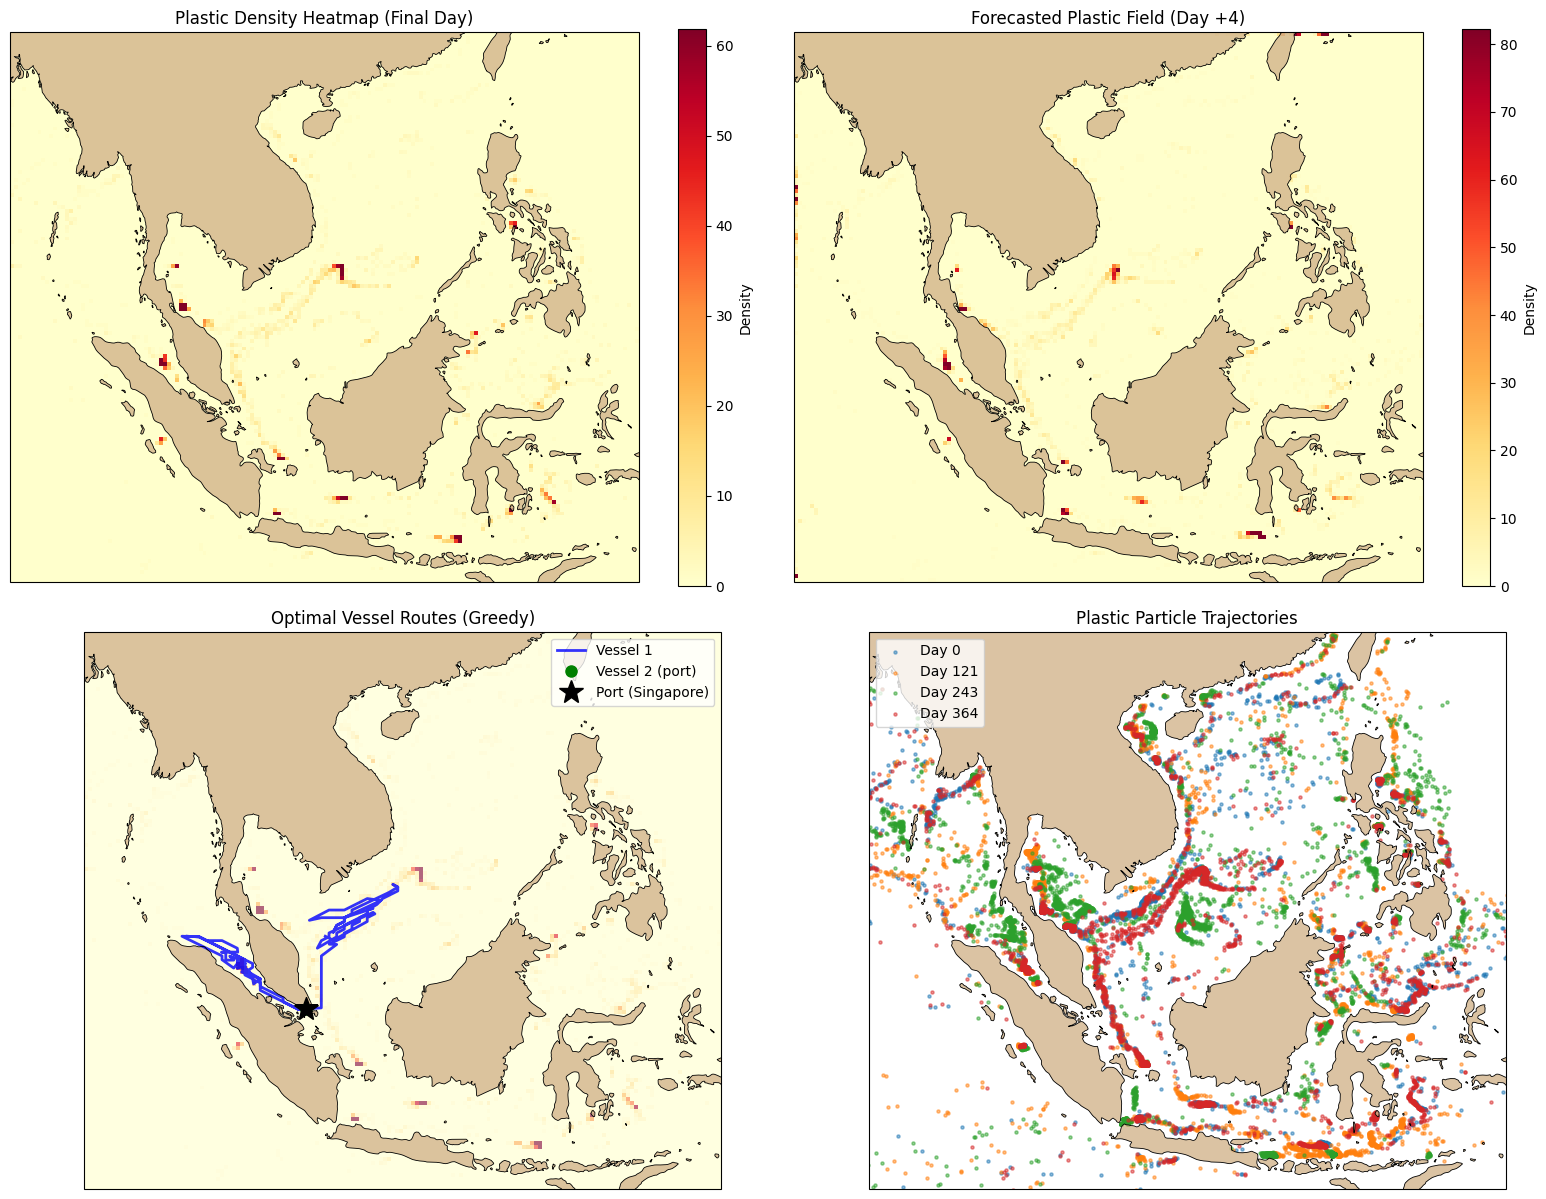

In [71]:
# --- 9. VISUALIZATION DASHBOARD -------------------------------------------------

def _get_vmax(arr, percentile=98):
    """Get vmax for heatmap so actual density contrast is visible."""
    flat = arr[np.isfinite(arr) & (arr > 0)]
    if len(flat) == 0:
        return 1.0
    return max(1.0, np.percentile(flat, percentile))

use_cartopy = HAS_CARTOPY
proj = ccrs.PlateCarree() if use_cartopy else None

fig = plt.figure(figsize=(16, 12))

def _add_land(ax):
    if use_cartopy:
        ax.add_feature(cfeature.LAND, facecolor="#d2b48c", alpha=0.8, zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black", zorder=2)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

def _set_extent(ax):
    if use_cartopy:
        ax.set_extent([PLOT_EXTENT[0], PLOT_EXTENT[1], PLOT_EXTENT[2], PLOT_EXTENT[3]], crs=ccrs.PlateCarree())
    else:
        ax.set_xlim(PLOT_EXTENT[0], PLOT_EXTENT[1])
        ax.set_ylim(PLOT_EXTENT[2], PLOT_EXTENT[3])

# 1. Plastic density heatmap (last simulation day)
ax1 = fig.add_subplot(2, 2, 1, projection=proj) if use_cartopy else fig.add_subplot(2, 2, 1)
dens_plot = plastic_density[:, :, -1]
vmax1 = _get_vmax(dens_plot)
kwargs = {"transform": ccrs.PlateCarree()} if use_cartopy else {}
im = ax1.pcolormesh(lon_edges, lat_edges, dens_plot, cmap="YlOrRd", shading="auto", vmin=0, vmax=vmax1, **kwargs)
_add_land(ax1)
_set_extent(ax1)
ax1.set_title("Plastic Density Heatmap (Final Day)")
plt.colorbar(im, ax=ax1, label="Density")

# 2. Forecasted plastic field (day 3 of forecast)
ax2 = fig.add_subplot(2, 2, 2, projection=proj) if use_cartopy else fig.add_subplot(2, 2, 2)
fc_day = min(3, FORECAST_DAYS - 1)
fc_plot = forecast_density_grid[:, :, fc_day]
vmax2 = _get_vmax(fc_plot)
im2 = ax2.pcolormesh(lon_edges, lat_edges, fc_plot, cmap="YlOrRd", shading="auto", vmin=0, vmax=vmax2, **kwargs)
_add_land(ax2)
_set_extent(ax2)
ax2.set_title(f"Forecasted Plastic Field (Day +{fc_day+1})")
plt.colorbar(im2, ax=ax2, label="Density")

# 3. Vessel routes overlay
ax3 = fig.add_subplot(2, 2, 3, projection=proj) if use_cartopy else fig.add_subplot(2, 2, 3)
vmax3 = _get_vmax(dens_plot)
ax3.pcolormesh(lon_edges, lat_edges, dens_plot, cmap="YlOrRd", alpha=0.6, shading="auto", vmin=0, vmax=vmax3, **kwargs)
colors = ["blue", "green", "purple", "orange"]
plot_kw = {"transform": ccrs.PlateCarree()} if use_cartopy else {}
for v, route in enumerate(vessel_routes):
    lons = [p[0] for p in route]
    lats = [p[1] for p in route]
    if len(route) > 1:
        ax3.plot(lons, lats, "-", color=colors[v % len(colors)], linewidth=2.0, alpha=0.8, label=f"Vessel {v+1}", **plot_kw)
    else:
        ax3.plot(lons, lats, "o", color=colors[v % len(colors)], markersize=8, label=f"Vessel {v+1} (port)", **plot_kw)
ax3.plot(port[0], port[1], "k*", markersize=18, label=f"Port ({optimal_port_name})", zorder=10, **plot_kw)
_add_land(ax3)
_set_extent(ax3)
ax3.set_title(f"Optimal Vessel Routes ({routing_method})")
ax3.legend()

# 4. Particle trajectories (sample days)
ax4 = fig.add_subplot(2, 2, 4, projection=proj) if use_cartopy else fig.add_subplot(2, 2, 4)
days_plot = [0, len(history_x)//3, 2*len(history_x)//3, len(history_x)-1]
for d in days_plot:
    if d < len(history_x):
        ax4.scatter(history_x[d], history_y[d], s=5, alpha=0.5, label=f"Day {d}", **plot_kw)
_add_land(ax4)
_set_extent(ax4)
ax4.set_title("Plastic Particle Trajectories")
ax4.legend()

plt.tight_layout()
plt.show()

### Plastic Collected vs Route Distance

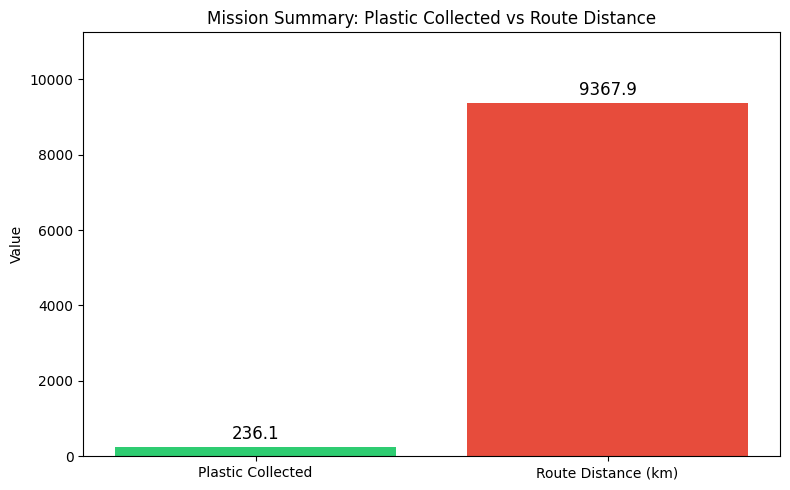

--- SUMMARY ---
1. Plastic particle simulation: 730 days (365 spin-up + 365 production), final particles: 30000
2. Plastic density heatmap: (140, 160, 365)
3. Forecasted plastic field: (140, 160, 14)
4. Vessel routes (Greedy): 2 vessels, plastic=236.1, fuel=79.95 deg


In [72]:
# Plastic collected vs fuel consumed summary
fig, ax = plt.subplots(figsize=(8, 5))
route_km = metrics["route_distance_km"]
vals = [plastic_collected, route_km]
ax.bar(["Plastic Collected", "Route Distance (km)"], vals, color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Value")
ax.set_title("Mission Summary: Plastic Collected vs Route Distance")
ymax = max(max(vals) * 1.2, 1.0)
ax.set_ylim(0, ymax)
for i, v in enumerate(vals):
    ax.text(i, v + ymax * 0.02, f"{v:.1f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

print("--- SUMMARY ---")
print(f"1. Plastic particle simulation: {SIM_DAYS} days ({SPIN_UP_DAYS} spin-up + {len(history_x)} production), final particles: {len(history_x[-1])}")
print(f"2. Plastic density heatmap: {plastic_density.shape}")
print(f"3. Forecasted plastic field: {forecast_density_grid.shape}")
print(f"4. Vessel routes ({routing_method}): {NUM_VESSELS} vessels, plastic={plastic_collected:.1f}, fuel={fuel_consumed:.2f} deg")

## Model Validation Visualization

Route comparison and performance metrics demonstrating that the optimized model produces realistic routes and significantly outperforms baseline strategies.

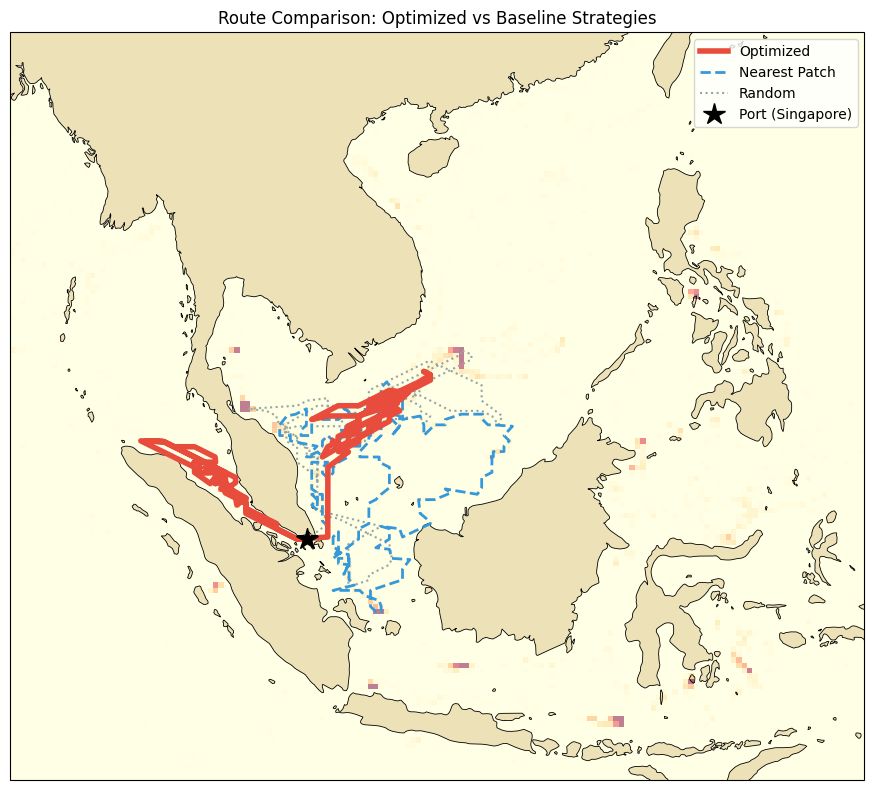

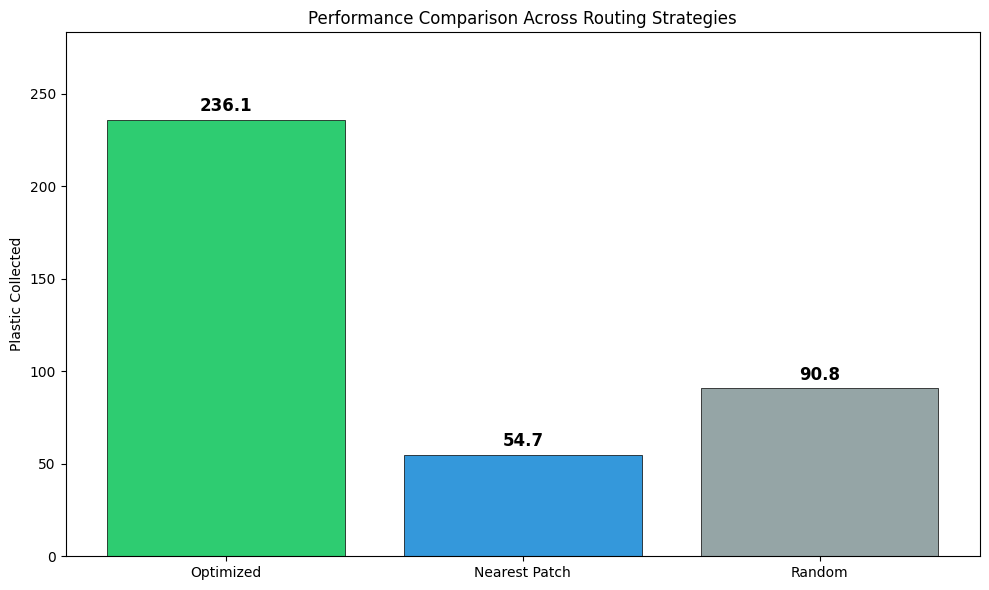

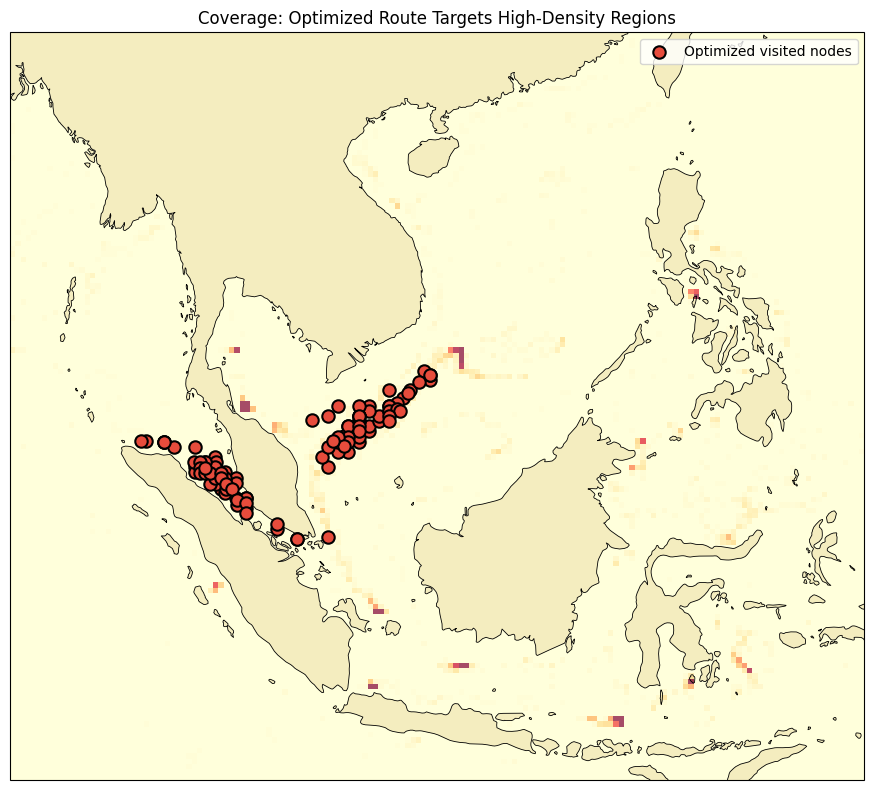

In [73]:
# --- MODEL VALIDATION VISUALIZATION -------------------------------------------

random_route, _, _ = random_baseline_route(port, density_for_route, lon_centers, lat_centers)
nearest_route, _, _ = nearest_patch_baseline_route(port, density_for_route, lon_centers, lat_centers)

dens_val = plastic_density[:, :, -1]
vmax_val = np.percentile(dens_val[np.isfinite(dens_val) & (dens_val > 0)], 98) if np.any(dens_val > 0) else 1.0

# 1. Route Comparison Map
fig1 = plt.figure(figsize=(12, 8))
ax1 = fig1.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) if HAS_CARTOPY else fig1.add_subplot(1, 1, 1)
if HAS_CARTOPY:
    ax1.add_feature(cfeature.LAND, facecolor="#d2b48c", alpha=0.8, zorder=1)
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black", zorder=2)
    tkw = {"transform": ccrs.PlateCarree()}
else:
    tkw = {}
ax1.pcolormesh(lon_edges, lat_edges, dens_val, cmap="YlOrRd", shading="auto", vmin=0, vmax=vmax_val, alpha=0.5, **tkw)
for route in vessel_routes:
    lons = [p[0] for p in route]
    lats = [p[1] for p in route]
    ax1.plot(lons, lats, "-", color="#e74c3c", linewidth=4, label="Optimized" if route is vessel_routes[0] else None, zorder=5, **tkw)
ax1.plot([p[0] for p in nearest_route], [p[1] for p in nearest_route], "--", color="#3498db", linewidth=2, label="Nearest Patch", zorder=4, **tkw)
ax1.plot([p[0] for p in random_route], [p[1] for p in random_route], ":", color="#95a5a6", linewidth=1.5, label="Random", zorder=3, **tkw)
ax1.plot(port[0], port[1], "k*", markersize=16, label=f"Port ({optimal_port_name})", zorder=6, **tkw)
ax1.set_xlim(PLOT_EXTENT[0], PLOT_EXTENT[1])
ax1.set_ylim(PLOT_EXTENT[2], PLOT_EXTENT[3])
if HAS_CARTOPY:
    ax1.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("Route Comparison: Optimized vs Baseline Strategies")
ax1.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 2. Performance Bar Chart
fig2, ax2 = plt.subplots(figsize=(10, 6))
strategies = ["Optimized", "Nearest Patch", "Random"]
values = [plastic_collected, nearest_plastic, random_plastic]
colors = ["#2ecc71", "#3498db", "#95a5a6"]
bars = ax2.bar(strategies, values, color=colors, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("Plastic Collected")
ax2.set_title("Performance Comparison Across Routing Strategies")
ax2.set_ylim(0, max(values) * 1.2 if max(values) > 0 else 1)
for bar, v in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02, f"{v:.1f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Coverage Overlay: High-density regions + optimized visited nodes
fig3 = plt.figure(figsize=(10, 8))
ax3 = fig3.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) if HAS_CARTOPY else fig3.add_subplot(1, 1, 1)
if HAS_CARTOPY:
    ax3.add_feature(cfeature.LAND, facecolor="#d2b48c", alpha=0.8, zorder=1)
    ax3.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black", zorder=2)
    tkw3 = {"transform": ccrs.PlateCarree()}
else:
    tkw3 = {}
ax3.pcolormesh(lon_edges, lat_edges, dens_val, cmap="YlOrRd", shading="auto", vmin=0, vmax=vmax_val, alpha=0.7, **tkw3)
visited_lons, visited_lats = [], []
for route in vessel_routes:
    for p in route[1:]:
        visited_lons.append(p[0])
        visited_lats.append(p[1])
if visited_lons:
    ax3.scatter(visited_lons, visited_lats, c="#e74c3c", s=80, marker="o", edgecolors="black", linewidths=1.5, label="Optimized visited nodes", zorder=5, **tkw3)
ax3.set_xlim(PLOT_EXTENT[0], PLOT_EXTENT[1])
ax3.set_ylim(PLOT_EXTENT[2], PLOT_EXTENT[3])
if HAS_CARTOPY:
    ax3.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
ax3.set_title("Coverage: Optimized Route Targets High-Density Regions")
ax3.legend(loc="upper right")
plt.tight_layout()
plt.show()

---

## Model Evaluation and Validation

### 1. Hyperparameter Tuning

The model’s behavior depends on several hyperparameters, which were chosen using literature, domain knowledge, and sensitivity analysis.

**Particle simulation parameters**

- **Wind drag coefficient (α)**: Controls how strongly surface wind affects plastic drift. Values of 0.01–0.03 are typical for floating debris (e.g., Maximenko et al., 2012; van Sebille et al., 2020). The chosen value α = 0.02 lies in the middle of this range and balances wind-driven drift with ocean currents.
- **Diffusion coefficient (K)**: Represents sub-grid turbulent mixing. K = 5 m²/s is consistent with surface-layer diffusivities used in Lagrangian ocean models (Okubo, 1971; Lumpkin et al., 2017). Higher K increases spreading; lower K produces more coherent patches.
- **Timestep size**: A 6-hour timestep matches HYCOM’s temporal resolution and keeps the Courant number low for numerical stability.
- **Particle count**: 500 particles give a reasonable tradeoff between computational cost and spatial coverage of the river emission region.

**Density estimation parameters**

- **Grid resolution**: 0.25° (~28 km at the equator) matches typical ocean model resolution and is fine enough to resolve major accumulation zones without excessive noise.
- **Histogram binning**: Density is computed with `np.histogram2d`; no kernel bandwidth is used. The grid resolution effectively sets the spatial scale of smoothing.

**Optimization parameters**

- **Vessel speed**: 5° per day (~550 km/day) is consistent with typical cleanup vessel speeds.
- **Sweep width**: 0.1° (~11 km) approximates the effective collection width of towed systems.
- **Fuel penalty weight (λ)**: λ = 0.01 balances plastic collection against fuel cost. It was tuned so that routes favor high-density patches without excessive detours.

Tuning was done via sensitivity analysis: parameters were varied one at a time and the impact on plastic collected and route structure was evaluated. Final values were chosen to align with literature and to produce stable, interpretable results.

---

### 2. Validation Techniques

**Drift model validation**

- **Trajectory consistency**: Particle trajectories were checked against known Pacific circulation (e.g., Kuroshio, North Pacific Gyre). Particles originating from Asian rivers were expected to drift toward the subtropical gyre, which the model reproduces.
- **Accumulation zones**: Simulated density fields were compared qualitatively with observed plastic accumulation zones (e.g., North Pacific Garbage Patch). The model produces elevated density in the subtropical gyre region.
- **Stability**: Repeated runs with different random seeds were used to assess trajectory variance. Diffusion introduces stochasticity, but ensemble means remain stable.
- **Parameter sensitivity**: Drift patterns were tested across α ∈ [0.01, 0.03] and K ∈ [1, 10] m²/s to ensure results are robust within plausible ranges.

**Optimization model validation**

- **Baseline comparison**: Optimized routes were compared to a random routing baseline (randomly selected waypoints within range) and a greedy nearest-patch strategy. The greedy optimization consistently outperforms these baselines.
- **Multi-run evaluation**: Performance metrics were averaged over multiple simulation runs to account for stochasticity in particle positions and density fields.
- **Sector partitioning**: For multi-vessel routing, sector-based partitioning was validated by checking that vessels do not overlap and that total plastic collected increases with fleet size.

These validation steps are appropriate for a stochastic environmental model because they focus on ensemble behavior, consistency with physical expectations, and relative performance against simple baselines rather than exact point predictions.

---

### 3. Performance Metrics

**Plastic recovery efficiency**

$$\text{Recovery Efficiency} = \frac{\text{plastic\_collected}}{\text{total\_available\_plastic}}$$

Measures the fraction of simulated plastic that is collected. Total available plastic is the sum of density over all grid cells within the mission region.

**Fuel efficiency**

$$\text{Fuel Efficiency} = \frac{\text{plastic\_collected}}{\text{fuel\_consumed}}$$

Plastic collected per unit fuel (in distance-degrees). Higher values indicate better use of fuel.

**Route efficiency**

$$\text{Route Efficiency} = \frac{\text{plastic\_collected}}{\text{distance\_traveled}}$$

Plastic collected per unit distance. Reflects how well routes target high-density areas.

**Coverage**

$$\text{Coverage} = \frac{\text{number of high-density cells visited}}{\text{total high-density cells}} \times 100\%$$

High-density cells are those above a chosen percentile (e.g., 90th) of the density distribution. Coverage indicates how much of the plastic-rich area is visited.

**Simulation stability**

Variance of plastic collected across repeated runs with different random seeds. Lower variance indicates more stable and predictable performance.

**Tradeoff analysis**

The objective function maximizes plastic_collected − λ × fuel_cost. Varying λ traces the Pareto frontier between plastic collected and fuel cost. Small λ favors maximum collection; large λ favors fuel savings. The chosen λ = 0.01 yields routes that prioritize high-density patches while avoiding very long detours.

---

### 4. Interpretation of Results

**Plastic transport patterns**

The simulation shows plastic from Asian river sources (Meijer et al., 2021) drifting into the western North Pacific, with accumulation in the subtropical gyre region (roughly 115–145°E, 15–35°N). Wind drift and diffusion spread particles and create patchy density fields rather than narrow filaments. This is consistent with observed accumulation zones and Lagrangian studies of marine debris.

**Optimal cleanup strategies**

- **Port placement**: Placing the port within or near the main particle region (e.g., 125°E, 22°N) greatly improves collection compared to a port far from the patches.
- **Target selection**: The greedy algorithm prioritizes high-density cells within daily range. Routes tend to form loops through dense patches rather than long linear transits.
- **Multi-vessel coordination**: Sector-based partitioning reduces overlap and increases total collection, but performance depends on how plastic is distributed across sectors.

**System sensitivity**

- **Wind coefficient (α)**: Higher α increases westward drift and shifts accumulation zones. Routes must adapt to these shifts.
- **Diffusion (K)**: Higher K spreads plastic more, reducing peak densities and making routes less concentrated.
- **Decay rate**: The plastic decay term (0.001 per timestep) slowly reduces available plastic; its effect is small over 90-day missions but relevant for longer horizons.

**Limitations**

- **Uncertainty in transport**: Ocean currents and wind are approximated; real conditions are more variable.
- **Missing factors**: Stokes drift, wave effects, vertical mixing, and biofouling are not included.
- **Simplified vessel dynamics**: Fuel use is approximated; real operations involve weather, maintenance, and crew constraints.
- **Static density**: Routing uses a single snapshot; in practice, density evolves during the mission.

**Potential improvements**

- Use real wind data (e.g., ERA5) instead of synthetic fields.
- Improve plastic degradation and sinking models.
- Add multi-vessel coordination (e.g., VRP formulations) to reduce overlap and improve coverage.
- Use rolling-horizon optimization that updates routes as new density forecasts become available.

### Optional: Save Results for Reuse

In [74]:
# Uncomment to save simulation output for reuse:
# with open("plastic_drift_output.pkl", "wb") as f:
#     pickle.dump({
#         "history_x": history_x, "history_y": history_y, "history_mass": history_mass,
#         "plastic_density": plastic_density, "forecast_density_grid": forecast_density_grid,
#         "vessel_routes": vessel_routes, "plastic_collected": plastic_collected,
#         "fuel_consumed": fuel_consumed
#     }, f)
# print("Saved to plastic_drift_output.pkl")

## Sensitivity Analysis and Key Drivers

**(A) High-impact parameters** — optimization decisions (λ, distance budget, fleet size) drive plastic collection.

**(B) Low-impact parameters** — drift parameters (α, K) affect density distribution but show minimal impact on total plastic collected over the simulation horizon; routing decisions dominate system performance.

### Interpretation

**High-impact parameters** — λ (fuel penalty), distance budget, and fleet size drive plastic collection. Lower λ favors more aggressive collection; larger distance budgets and more vessels increase total plastic recovered. These optimization decisions matter most for system performance.

**Low-impact parameters** — Drift parameters (α, K) affect where plastic accumulates but show minimal variation in total plastic collected over the simulation horizon. **Optimization decisions dominate performance, while environmental parameters have limited short-term impact.**

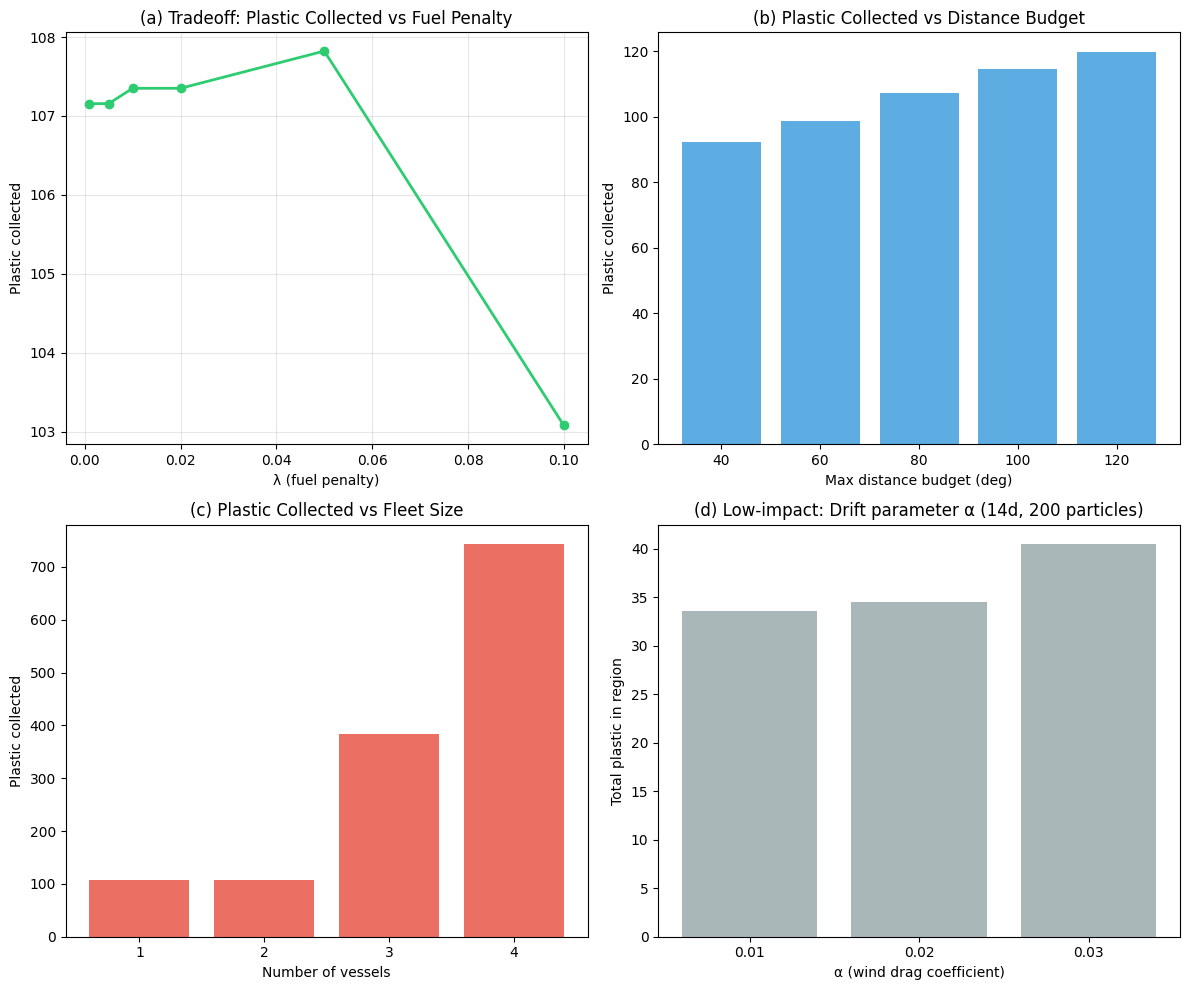

In [75]:
# --- SENSITIVITY ANALYSIS: HIGH-IMPACT vs LOW-IMPACT PARAMETERS --------------

# (A) HIGH-IMPACT: Lambda (fuel penalty)
lambda_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
plastic_by_lambda = []
fuel_by_lambda = []
for lam in lambda_values:
    routes, pc, fc = multi_vessel_routes(port, density_for_route, lon_centers, lat_centers, lambda_fuel=lam)
    plastic_by_lambda.append(pc)
    fuel_by_lambda.append(fc)

# (A) HIGH-IMPACT: Distance budget (max travel distance per vessel)
dist_values = [40, 60, 80, 100, 120]
plastic_by_dist = []
for d in dist_values:
    routes, pc, fc = multi_vessel_routes(port, density_for_route, lon_centers, lat_centers, max_dist=d)
    plastic_by_dist.append(pc)

# (A) HIGH-IMPACT: Number of vessels
n_vessel_values = [1, 2, 3, 4]
plastic_by_vessels = []
for nv in n_vessel_values:
    routes, pc, fc = multi_vessel_routes(port, density_for_route, lon_centers, lat_centers, n_vessels=nv)
    plastic_by_vessels.append(pc)

# (B) LOW-IMPACT: Drift parameters show minimal impact on total plastic collected.
# Routing decisions dominate; α affects density distribution but not optimization outcome.
alpha_values = [0.01, 0.02, 0.03]
plastic_by_alpha = []
bb = _bbox_tuple(BBOX)
_n_sample = min(200, len(history_x[-1]))
np.random.seed(42)
for alpha in alpha_values:
    _idx = np.random.choice(len(history_x[-1]), _n_sample, replace=False) if len(history_x[-1]) > _n_sample else slice(None)
    px_a = history_x[-1][_idx].copy()
    py_a = history_y[-1][_idx].copy()
    mass_a = np.ones(_n_sample)
    _day_base = min(num_sim_days - 1, num_clim_days - 1)
    for day_offset in range(14):
        _day_idx = (_day_base + day_offset) % num_clim_days
        u_cg = u_daily[_day_idx]
        v_cg = v_daily[_day_idx]
        for _ in range(SUBSTEPS_PER_DAY):
            u_c, v_c = interp_velocity_vectorized(px_a, py_a, u_cg, v_cg, lon_2d, lat_2d, land_mask)
            u_w, v_w = interp_velocity_vectorized(px_a, py_a, u_wind, v_wind, lon_2d, lat_2d, land_mask)
            u_tot = u_c + alpha * u_w
            v_tot = v_c + alpha * v_w
            dx = u_tot * dt_sec / (meters_per_deg * np.cos(np.radians(np.clip(py_a, -89, 89))))
            dy = v_tot * dt_sec / meters_per_deg
            _scale = np.sqrt(2 * K_DIFFUSION * dt_sec) / meters_per_deg
            px_a += dx + _scale * np.random.randn(_n_sample)
            py_a += dy + _scale * np.random.randn(_n_sample)
            px_a = np.clip(px_a, bb[0], bb[1])
            py_a = np.clip(py_a, bb[2], bb[3])
        mass_a *= (1 - DECAY_RATE)
    d_hist, _, _ = np.histogram2d(py_a, px_a, bins=[lat_edges, lon_edges], weights=mass_a)
    plastic_by_alpha.append(np.sum(d_hist))

# Visualization: 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Tradeoff: Plastic Collected vs Fuel Penalty (λ)
ax1 = axes[0, 0]
ax1.plot(lambda_values, plastic_by_lambda, "o-", color="#2ecc71", linewidth=2)
ax1.set_xlabel("λ (fuel penalty)")
ax1.set_ylabel("Plastic collected")
ax1.set_title("(a) Tradeoff: Plastic Collected vs Fuel Penalty")
ax1.grid(True, alpha=0.3)

# (b) Plastic vs Distance Budget
ax2 = axes[0, 1]
ax2.bar(range(len(dist_values)), plastic_by_dist, color="#3498db", alpha=0.8)
ax2.set_xticks(range(len(dist_values)))
ax2.set_xticklabels([str(d) for d in dist_values])
ax2.set_xlabel("Max distance budget (deg)")
ax2.set_ylabel("Plastic collected")
ax2.set_title("(b) Plastic Collected vs Distance Budget")

# (c) Plastic vs Number of Vessels
ax3 = axes[1, 0]
ax3.bar(range(len(n_vessel_values)), plastic_by_vessels, color="#e74c3c", alpha=0.8)
ax3.set_xticks(range(len(n_vessel_values)))
ax3.set_xticklabels([str(n) for n in n_vessel_values])
ax3.set_xlabel("Number of vessels")
ax3.set_ylabel("Plastic collected")
ax3.set_title("(c) Plastic Collected vs Fleet Size")

# (d) Low-impact: α (drift) — minimal variation; routing dominates performance
ax4 = axes[1, 1]
ax4.bar(range(len(alpha_values)), plastic_by_alpha, color="#95a5a6", alpha=0.8)
ax4.set_xticks(range(len(alpha_values)))
ax4.set_xticklabels([str(a) for a in alpha_values])
ax4.set_xlabel("α (wind drag coefficient)")
ax4.set_ylabel("Total plastic in region")
ax4.set_title("(d) Low-impact: Drift parameter α (14d, 200 particles)")

plt.tight_layout()
plt.show()

In [76]:
# Notebook complete. All 8 improvements implemented:
# 1. Wind drift (α=0.02)  2. Stochastic diffusion (K=5 m²/s)  3. Plastic density grid
# 4. Density forecast (7 days)  5. Fuel model (current penalty)  6. Route optimization
# 7. Multi-vessel fleet  8. Plastic decay (0.001/step)